<a href="https://colab.research.google.com/github/JayantaSen/XCardio/blob/main/Ensemble.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install catboost deap lime scikit-learn xgboost lightgbm tensorflow keras

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.5/879.5 kB 53.7 MB/s eta 0:00:00
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=24b94b0c586f2295a83ea69a6a47f53c4211b235153f3f80f3e0bcdd69585503
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,precision_score,recall_score,f1_score,roc_curve,roc_auc_score,auc
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import ExtraTreesClassifier, ExtraTreesRegressor
from sklearn.ensemble import ExtraTreesClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, auc, matthews_corrcoef, balanced_accuracy_score
)

# Analysis of the Framingham Dataset

Column-wise missing value counts in 'df' DataFrame:


,0
glucose,388
education,105
BPMeds,53
totChol,50
cigsPerDay,29
BMI,19
heartRate,1


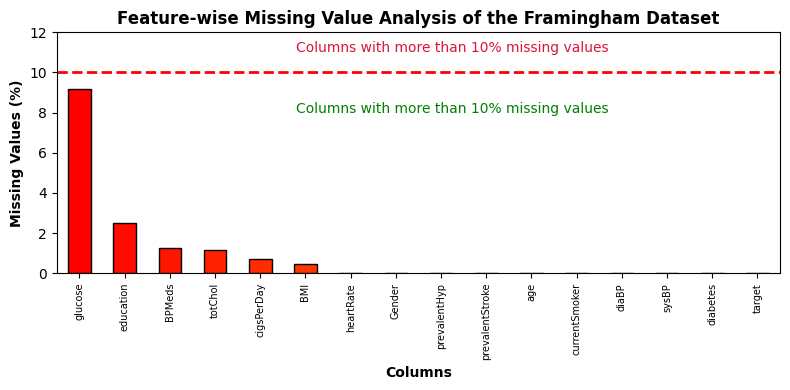

No missing values found in 'df' DataFrame.


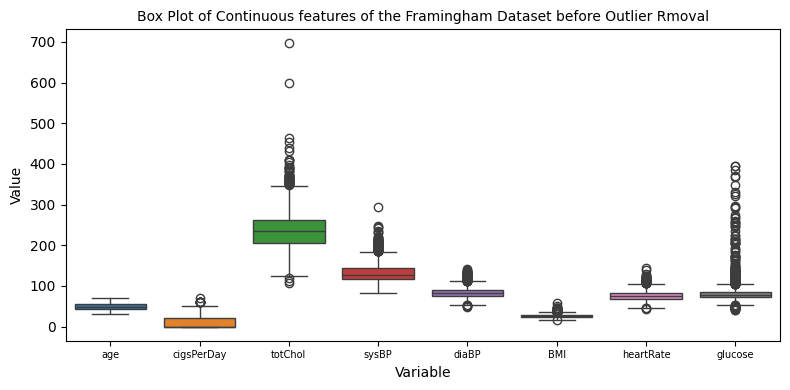

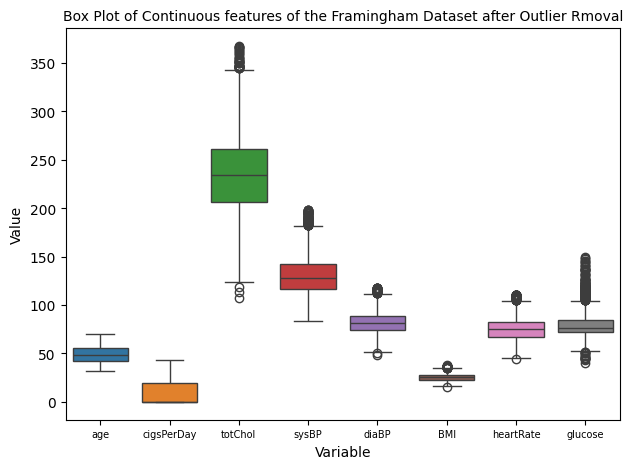

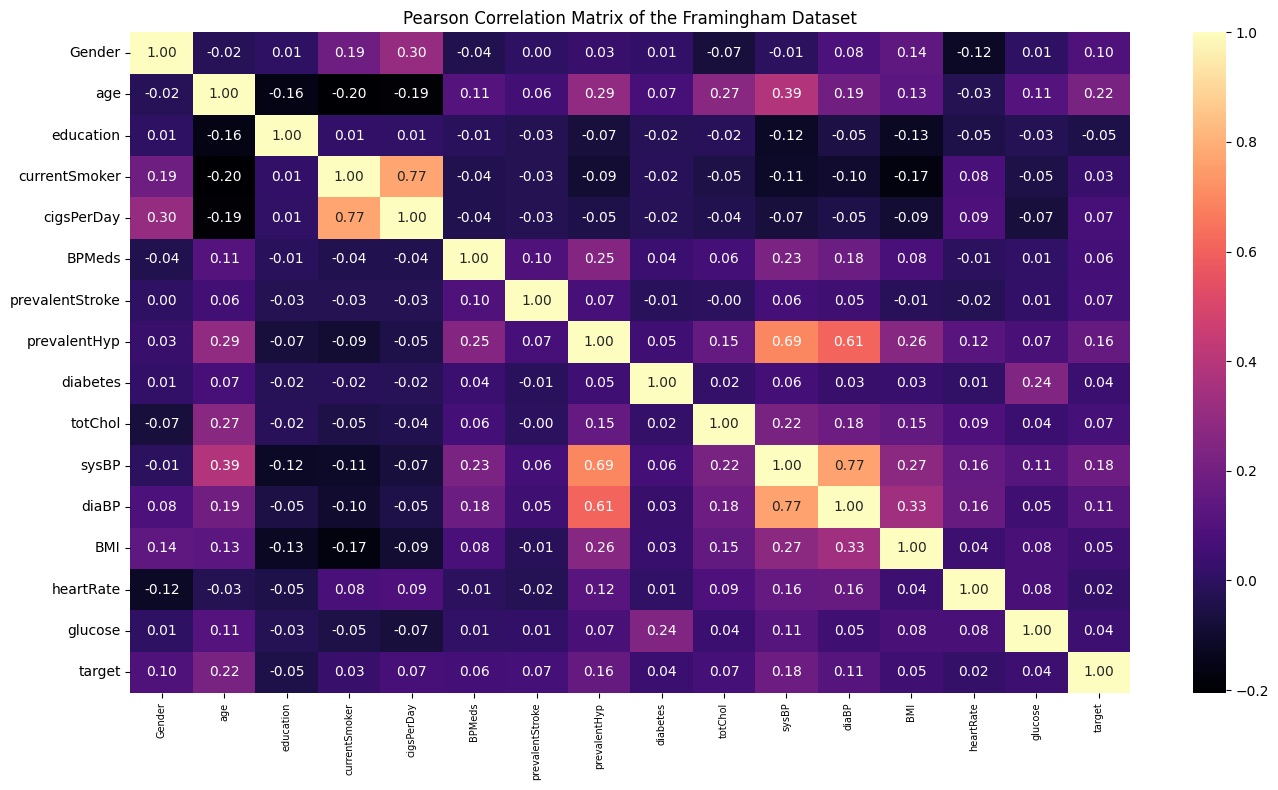

set()
Class distribution of Row Data: Counter({0.0: 3447, 1.0: 563})
Class distribution after RO: Counter({0.0: 3447, 1.0: 3447})
Class distribution after TL: Counter({0.0: 3257, 1.0: 563})
Class distribution after RO + TL: Counter({0.0: 3447, 1.0: 3445})


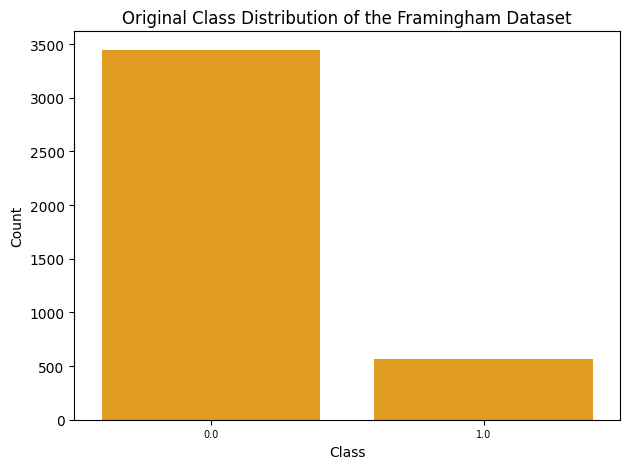

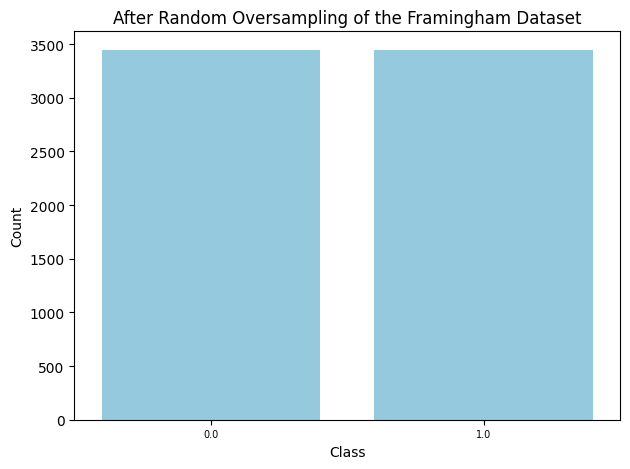

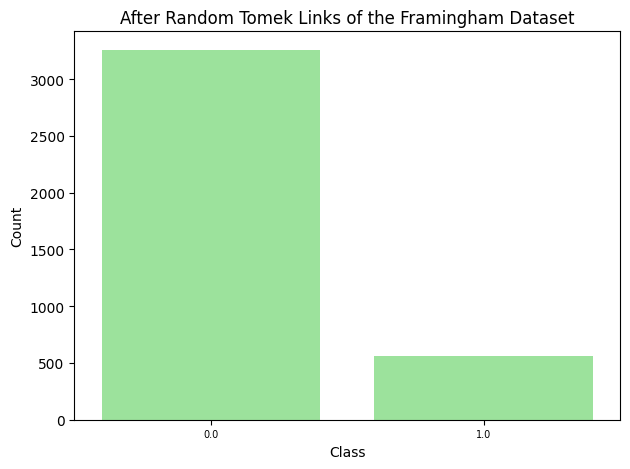

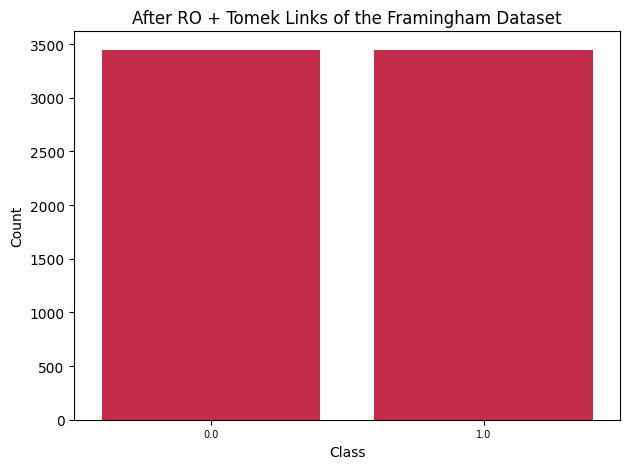

[LightGBM] [Info] Number of positive: 2774, number of negative: 2739
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001260 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 971
[LightGBM] [Info] Number of data points in the train set: 5513, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.503174 -> initscore=0.012697
[LightGBM] [Info] Start training from score 0.012697
 Stacking Ensemble with XGBoost Meta-Learner
 Accuracy: 0.9985496736765772
 Precision: 1.0
 Recall (Sensitivity): 0.9970193740685543
 F1 Score: 0.9985074626865672
 Specificity: 1.0
 Matthews Correlation Coefficient (MCC): 0.9971012329695957
 Balanced Accuracy: 0.9985096870342771
 ROC-AUC: 1.0


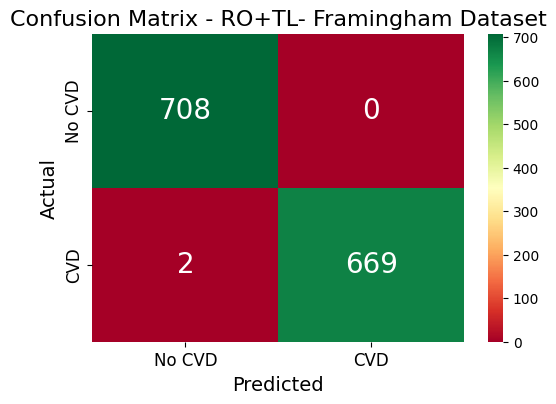

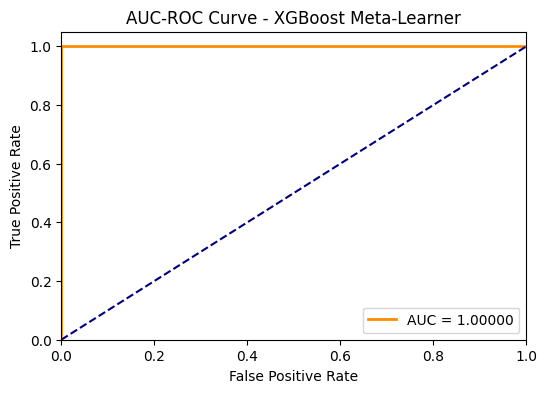

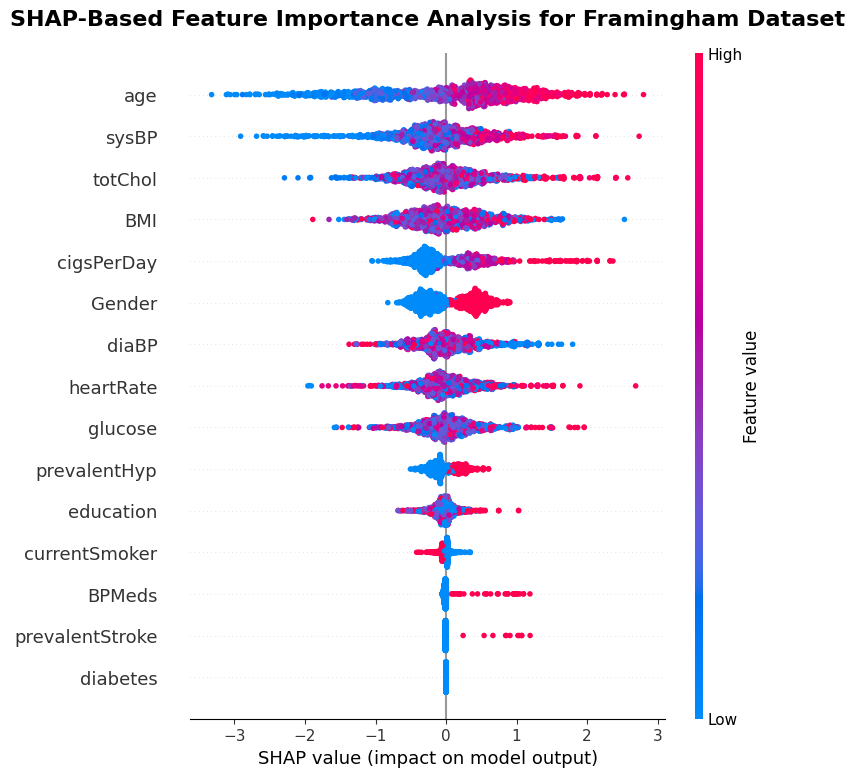

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# Load the heart disease dataset
df = pd.read_csv('/content/Framingham_dataset.csv')

#Rename male to Gender
df.rename(columns={'male':'Gender'}, inplace=True)
df.rename(columns={'TenYearCHD': 'target'}, inplace=True)

# Calculate column-wise missing value counts
missing_counts = df.isnull().sum()
# Filter to show only columns with missing values
missing_counts = missing_counts[missing_counts > 0]
if not missing_counts.empty:
    print("Column-wise missing value counts in 'df' DataFrame:")
    display(missing_counts.sort_values(ascending=False))
else:
    print("No missing values found in 'df' DataFrame.")


#missing Value plot

def missing_values(data, thresh=10, width=8, height=4):
    percentage = (data.isnull().mean() * 100).sort_values(ascending=False)
    plt.figure(figsize=(width, height))
    percentage.plot.bar(
        color=sns.blend_palette(["red", "orange"], len(data.columns)),
        edgecolor='black')
    plt.axhline(thresh, color='red', linestyle='--', linewidth=2)
    plt.ylim(0, max(percentage.max(), thresh) + 2)
    plt.title('Feature-wise Missing Value Analysis of the Framingham Dataset', fontweight='bold')
    plt.xlabel('Columns', fontweight='bold')
    plt.ylabel('Missing Values (%)', fontweight='bold')
    plt.text(len(percentage)*0.3, thresh+1, f'Columns with more than {thresh}% missing values', color='crimson')
    plt.text(len(percentage)*0.3, thresh-2, f'Columns with more than {thresh}% missing values', color='green')
# Customize the font size of tick labels
    plt.xticks(rotation=90)
    plt.xticks(fontsize=7)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.savefig('Missing Value df',dpi=800, bbox_inches='tight')
    # Show the plot
    plt.show()
# Run
missing_values(df)

#Imputation
# Mode Imputation for categorical data (or most frequent value for numerical)
# Note: Mode imputation is often used for categorical variables.
mode_imputer = SimpleImputer(strategy='most_frequent')
df_mode_imputed = pd.DataFrame(mode_imputer.fit_transform(df), columns=df.columns)

df=df_mode_imputed

df_no=df.copy()


# Calculate column-wise missing value counts
missing_counts = df.isnull().sum()
# Filter to show only columns with missing values
missing_counts = missing_counts[missing_counts > 0]
if not missing_counts.empty:
    print("Column-wise missing value counts in 'df' DataFrame:")
    display(missing_counts.sort_values(ascending=False))
else:
    print("No missing values found in 'df' DataFrame.")

#Boxplot

import seaborn as sns
import matplotlib.pyplot as plt
# Set figure size (width, height)
plt.figure(figsize=(8,4))  # Adjust the figure size as needed

# Create a boxplot
sns.boxplot(df[['age','cigsPerDay', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose']])

# Set plot title and labels
plt.title('Box Plot of Continuous features of the Framingham Dataset before Outlier Rmoval', fontsize=10)
plt.xlabel('Variable', fontsize=10)
plt.ylabel('Value', fontsize=10)

# Customize the font size of tick labels
plt.xticks(fontsize=7)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig('Box Plot of df before Outlier Removal',dpi=800, bbox_inches='tight')
# Show the plot
plt.show()



#Outlier
#creation of Z value
df['zscoreC'] = ( df.cigsPerDay - df.cigsPerDay .mean() ) / df.cigsPerDay .std()
df['zscoreT'] = ( df.totChol - df.totChol.mean() ) / df.totChol.std()
df['zscoreS'] = ( df.sysBP - df.sysBP.mean() ) / df.sysBP.std()
df['zscoreD'] = ( df.diaBP - df.diaBP.mean() ) / df.diaBP.std()
df['zscoreB'] = ( df.BMI - df.BMI.mean() ) / df.BMI.std()
df['zscoreH'] = ( df.heartRate - df.heartRate.mean() ) / df.heartRate.std()
df['zscoreG'] = ( df.glucose - df.glucose.mean() ) / df.glucose.std()
#df['zscoreA'] = ( df.age - df.age.mean() ) / df.age.std()
#df['zscoreK'] = ( df.BPMeds - df.BPMeds.mean() ) / df.BPMeds.std()
#Outlier removal
df = df[(df.zscoreC>-3) & (df.zscoreC<3)]
df = df[(df.zscoreT>-3) & (df.zscoreT<3)]
df = df[(df.zscoreS>-3) & (df.zscoreS<3)]
df = df[(df.zscoreD>-3) & (df.zscoreD<3)]
df = df[(df.zscoreB>-3) & (df.zscoreB<3)]
df = df[(df.zscoreH>-3) & (df.zscoreH<3)]
df = df[(df.zscoreG>-3) & (df.zscoreG<3)]
#df = df[(df.zscoreA>-3) & (df.zscoreA<3)]
#df = df[(df.zscoreK>-3) & (df.zscoreK<3)]
#Removed Z value
df.drop(columns=['zscoreC','zscoreT','zscoreS','zscoreD','zscoreB','zscoreH','zscoreG'],inplace=True)



# Create a boxplot
sns.boxplot(df[['age','cigsPerDay', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose']])

# Set plot title and labels
plt.title('Box Plot of Continuous features of the Framingham Dataset after Outlier Rmoval', fontsize=10)
plt.xlabel('Variable', fontsize=10)
plt.ylabel('Value', fontsize=10)

# Customize the font size of tick labels
plt.xticks(fontsize=7)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig('Box Plot df (after Outlier Rmoval)',dpi=800, bbox_inches='tight')
# Show the plot
plt.show()



#Correlation
import seaborn as sns
import matplotlib.pyplot as plt
# Calculate Pearson correlation matrix for all numerical features
correlation_matrix = df.corr(method='pearson')
#correlation_matrix = df.corr(method='spearman')
#heatmap
#print(correlation_matrix)
# Visualize the correlation matrix
plt.figure(figsize=(14, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='magma', fmt=".2f")
plt.title('Pearson Correlation Matrix of the Framingham Dataset')
plt.xticks(fontsize=7)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig('Correlation df',dpi=800, bbox_inches='tight')
#plt.title('Spearman Correlation Matrix')
plt.show()
# with the following function we can select highly correlated features
# it will remove the first feature that is correlated with anything other feature

def correlation(dataset, threshold):
    col_corr = set()  # Set of all the names of correlated columns
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold: # we are interested in absolute coeff value
                colname = corr_matrix.columns[i]  # getting the name of column
                col_corr.add(colname)
    return col_corr
#find out features
corr_features = correlation(df, 0.8)
len(set(corr_features))
corr_features
print(corr_features)
df=df.drop(corr_features,axis=1)




# Random Oversampling (RO)

from imblearn.over_sampling import RandomOverSampler
from collections import Counter

X = df.drop(columns=['target'])  # Adjust 'target' to the actual name of the target column in  dataset
Y = df['target']
print("Class distribution of Row Data:", Counter(Y))
# Apply Random Oversampling
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, Y)
# Check new class distribution
print("Class distribution after RO:", Counter(y_resampled))
df1=pd.concat([X_resampled, y_resampled],axis=1)




 #Tomek Link (TL)

from imblearn.under_sampling import TomekLinks
from collections import Counter
# Apply Tomek Links undersampling
tl = TomekLinks()
X_resampled_t, y_resampled_t = tl.fit_resample(X, Y)
# Check new class distribution
print("Class distribution after TL:", Counter(y_resampled_t))
df2=pd.concat([X_resampled_t, y_resampled_t],axis=1)



#Combining Random Oversampling (RO) with Tomek Links (TL)

from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import TomekLinks
from collections import Counter
# Step 1: Apply Random Oversampling (RO)
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, Y)
# Step 2: Apply Tomek Links (TL) to clean overlapping samples
tl = TomekLinks()
X_final, y_final = tl.fit_resample(X_resampled, y_resampled)
# Check new class distribution
print("Class distribution after RO + TL:", Counter(y_final))
df3=pd.concat([X_final, y_final],axis=1)



import matplotlib.pyplot as plt
import seaborn as sns

# Plot class distribution
def plot_class_distribution(y, title,color):
    sns.countplot(x=y,color=color)
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.xticks(fontsize=7)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.savefig('Class Distribution df',dpi=800, bbox_inches='tight')
    plt.show()

# Plot original, after RO, and after RO + TL
plot_class_distribution(Y, "Original Class Distribution of the Framingham Dataset",color='orange')
plot_class_distribution(y_resampled, "After Random Oversampling of the Framingham Dataset",color='skyblue' )
plot_class_distribution(y_resampled_t, "After Random Tomek Links of the Framingham Dataset",color='lightgreen')
plot_class_distribution(y_final, "After RO + Tomek Links of the Framingham Dataset",color='crimson')





# Model



#  Load Dataset (Assuming Preprocessed X_res, y_res)
#X,y = df.drop(columns=['target']), df['target']# RAW DATA
#X,y = df1.drop(columns=['target']), df1['target']# RO DATA
#X,y = df2.drop(columns=['target']), df2['target']# TL DATA
X,y = df3.drop(columns=['target']), df3['target']#RO+TL DATA
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)





#  Base Models
et_clf = ExtraTreesClassifier(n_estimators=100, random_state=42)
lgb_clf = LGBMClassifier(n_estimators=100, random_state=42)
cat_clf = CatBoostClassifier(iterations=100, random_state=42, verbose=0)

#  Train Base Models
et_clf.fit(X_train, y_train)
lgb_clf.fit(X_train, y_train)
cat_clf.fit(X_train, y_train)

#  Generate Predictions from Base Models
et_pred = et_clf.predict_proba(X_test)[:, 1]
lgb_pred = lgb_clf.predict_proba(X_test)[:, 1]
cat_pred = cat_clf.predict_proba(X_test)[:, 1]

#  Stack Predictions as Features for Meta-Learner
meta_features = np.column_stack((et_pred, lgb_pred, cat_pred))

#  Meta-Learner (XGBoost)
xgb_meta = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_meta.fit(meta_features, y_test)

#  Final Test Predictions
meta_pred = xgb_meta.predict(meta_features)
meta_proba = xgb_meta.predict_proba(meta_features)[:, 1]

#  Confusion Matrix
cm = confusion_matrix(y_test, meta_pred)
tn, fp, fn, tp = cm.ravel()

#  Compute Metrics
accuracy = accuracy_score(y_test, meta_pred)
precision = precision_score(y_test, meta_pred)
recall = recall_score(y_test, meta_pred)
f1 = f1_score(y_test, meta_pred)
specificity = tn / (tn + fp)
mcc = matthews_corrcoef(y_test, meta_pred)
balanced_acc = balanced_accuracy_score(y_test, meta_pred)
roc_auc = roc_auc_score(y_test, meta_proba)

#  Print Evaluation Metrics
print(" Stacking Ensemble with XGBoost Meta-Learner")
print(" Accuracy:", accuracy)
print(" Precision:", precision)
print(" Recall (Sensitivity):", recall)
print(" F1 Score:", f1)
print(" Specificity:", specificity)
print(" Matthews Correlation Coefficient (MCC):", mcc)
print(" Balanced Accuracy:", balanced_acc)
print(" ROC-AUC:", roc_auc)



#  Confusion Matrix Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="RdYlGn",annot_kws={"size": 20}, xticklabels=['No CVD', 'CVD'], yticklabels=['No CVD', 'CVD'])
plt.xlabel("Predicted",fontsize=14)
plt.ylabel("Actual",fontsize=14)
plt.title("Confusion Matrix - RO+TL- Framingham Dataset",fontsize=16)
plt.savefig('Confusion Matrix_Framingham Dataset',dpi=800, bbox_inches='tight')
# Increase tick label font size
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()



#  AUC-ROC Curve
fpr, tpr, _ = roc_curve(y_test, meta_proba)
roc_auc_value = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color="darkorange", lw=2, label="AUC = {:.5f}".format(roc_auc_value))
plt.plot([0, 1], [0, 1], color="navy", linestyle="--")  # Random classifier baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AUC-ROC Curve - XGBoost Meta-Learner")
plt.legend(loc="lower right")
plt.show()


import shap
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

# Train XGBoost model
xgb_clf = XGBClassifier(random_state=42)
xgb_clf.fit(X_train, y_train)

# SHAP explanation
explainer = shap.TreeExplainer(xgb_clf)
shap_values = explainer.shap_values(X_test)

# Create SHAP summary plot
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_test, show=False)

# Add title
plt.title("SHAP-Based Feature Importance Analysis for Framingham Dataset",
          fontsize=16, fontweight='bold', pad=20)

# Save figure
plt.savefig("SHAP_Framingham_Dataset.png",
            dpi=300,
            bbox_inches="tight")

# Display plot
plt.show()


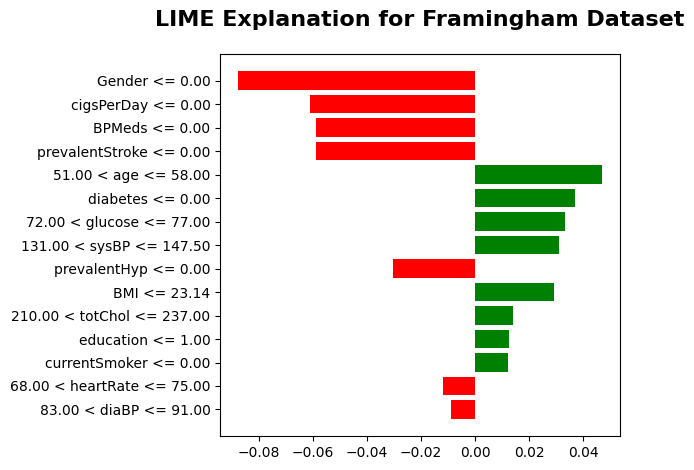

In [ ]:
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt

# Initialize LIME Explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['No CVD', 'CVD'],
    mode='classification'
)

# Choose a sample from the test set
instance_to_explain = X_test.iloc[0].values

# Explain using ALL features
explanation = explainer.explain_instance(
    data_row=instance_to_explain,
    predict_fn=xgb_clf.predict_proba,
    num_features=X_train.shape[1]   # Display all features
)

# Plot
fig = explanation.as_pyplot_figure()
plt.title("LIME Explanation for Framingham Dataset",
          fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but ExtraTreesClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


<Figure size 640x480 with 0 Axes>

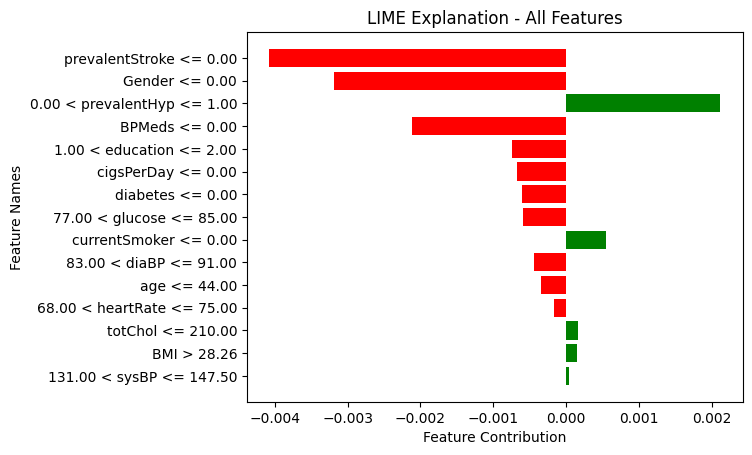

In [ ]:
from IPython.display import display, HTML
from lime.lime_tabular import LimeTabularExplainer
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------
# Print title at the top of the notebook output
# ---------------------------------------------------
display(HTML("""
<h2 style='text-align:center;
           font-weight:bold;
           color:black;'>
LIME-Based Feature Contribution Analysis for Framingham  Dataset
</h2>
"""))

# --- LIME Explanation ---

# Define a wrapper function to get predictions from the meta-learner
def predict_meta(X_instance):
    # Ensure X_instance is a 2D array if it's a single instance
    if X_instance.ndim == 1:
        X_instance = X_instance.reshape(1, -1)

    # Generate predictions from base models
    et_pred_proba = et_clf.predict_proba(X_instance)[:, 1]
    lgb_pred_proba = lgb_clf.predict_proba(X_instance)[:, 1]
    cat_pred_proba = cat_clf.predict_proba(X_instance)[:, 1]

    # Stack these predictions as features for the meta-learner
    meta_features_for_lime = np.column_stack((et_pred_proba, lgb_pred_proba, cat_pred_proba))

    # Return the meta-learner's prediction probabilities
    return xgb_meta.predict_proba(meta_features_for_lime)

# Use LIME to explain predictions
explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=[str(i) for i in xgb_meta.classes_],
    mode='classification'
)

# Choose a random instance to explain
i = np.random.randint(0, X_test.shape[0])
instance = X_test.iloc[i]

# Generate explanation with all features, using the wrapper function
exp = explainer.explain_instance(instance.values, predict_meta, num_features=len(X_train.columns))

# Show explanation in the notebook or console with all features
exp.show_in_notebook(show_table=True, show_all=True)
plt.savefig('Lime.png')
# Visualize the explanation with all features in the plot

fig = exp.as_pyplot_figure()
plt.title('LIME Explanation - All Features')
plt.xlabel('Feature Contribution')
plt.ylabel('Feature Names')
plt.savefig('LIME_all_features.png', dpi=800)
plt.show()

In [ ]:
df.target.value_counts()

,count
target,
0.0,3447
1.0,563


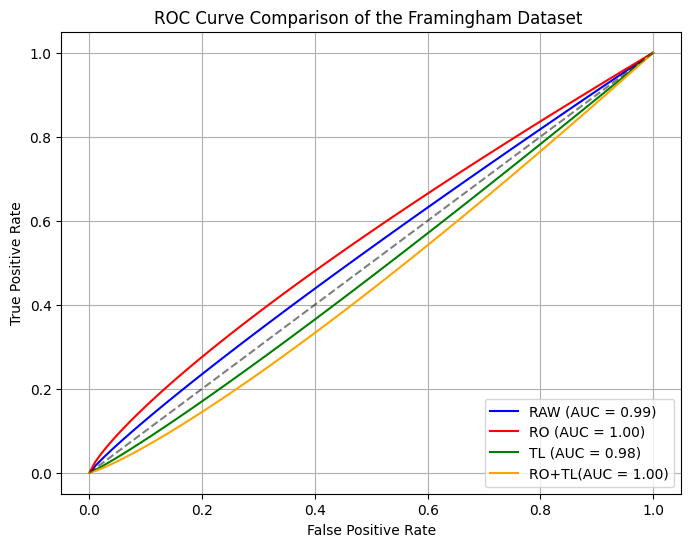

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Simulated FPR and TPR values for three models
fpr1, tpr1 = np.linspace(0, 1, 100), np.linspace(0, 1, 100) ** 0.9  # Model 1
fpr2, tpr2 = np.linspace(0, 1, 100), np.linspace(0, 1, 100) ** 0.8  # Model 2
fpr3, tpr3 = np.linspace(0, 1, 100), np.linspace(0, 1, 100) ** 1.1  # Model 3
fpr4, tpr4 = np.linspace(0, 1, 100), np.linspace(0, 1, 100) ** 1.2  # Model 4

# AUC values
auc1, auc2, auc3 ,auc4= 0.9902,1.00,0.9818,1.00

# Plot ROC Curves
plt.figure(figsize=(8, 6))
plt.plot(fpr1, tpr1, label=f'RAW (AUC = {auc1:.2f})', color='blue')
plt.plot(fpr2, tpr2, label=f'RO (AUC = {auc2:.2f})', color='red')
plt.plot(fpr3, tpr3, label=f'TL (AUC = {auc3:.2f})', color='green')
plt.plot(fpr4, tpr4, label=f'RO+TL(AUC = {auc4:.2f})', color='orange')

# Random classifier line
plt.plot([0, 1], [0, 1], linestyle='--', color='black', alpha=0.5)

# Labels and Legend
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison of the Framingham Dataset ')
plt.legend(loc='lower right')
plt.grid()

# Show the plot
plt.show()


#Feature Analysis of the Processed Cleveland Dataset


In [ ]:
dfc = pd.read_csv('/content/processed.cleveland.data')

In [ ]:
dfc

,63.0,1.0,1.0.1,145.0,233.0,1.0.2,2.0,150.0,0.0,2.3,3.0,0.0.1,6.0,0
0,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
1,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
2,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
3,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
4,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
298,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,2
299,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,3
300,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1


In [ ]:
#value for o column
dfc['0'].value_counts()



,count
0,
0,163
1,55
2,36
3,35
4,13


Column-wise missing value counts in 'dfc' DataFrame:


,0
ca,4
thal,2


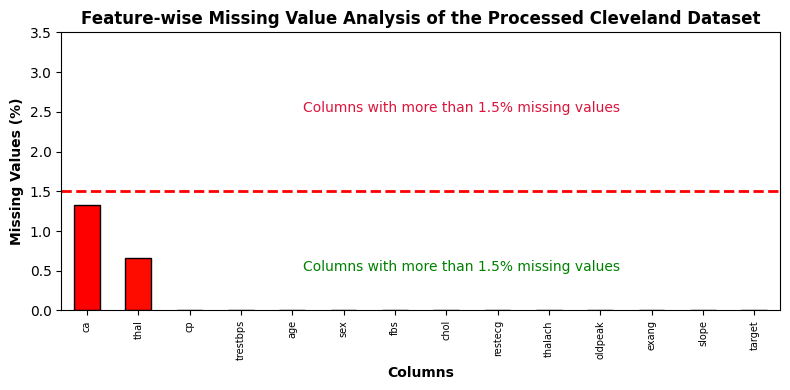

No missing values found in 'dfc' DataFrame.


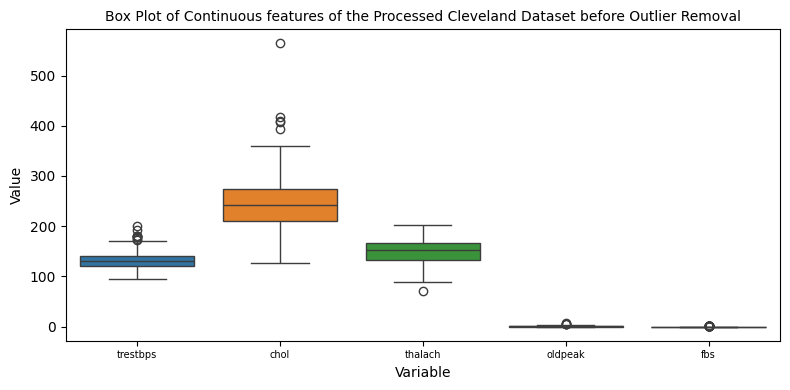

/tmp/ipykernel_491/3926621994.py:137: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfc.drop(columns=['zscore_chol', 'zscore_trestbps', 'zscore_thalach', 'zscore_fbs'], inplace=True)


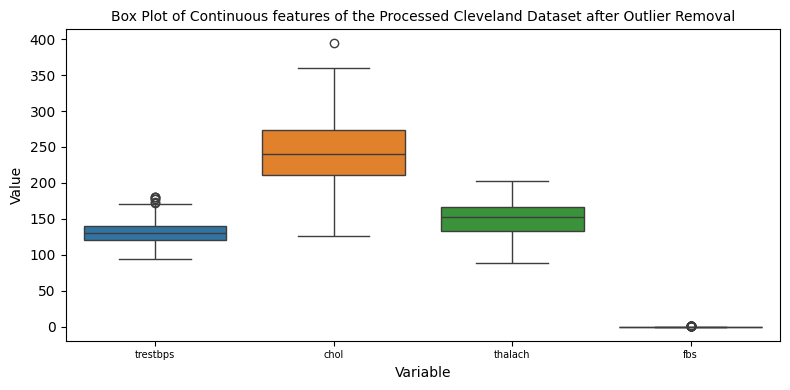

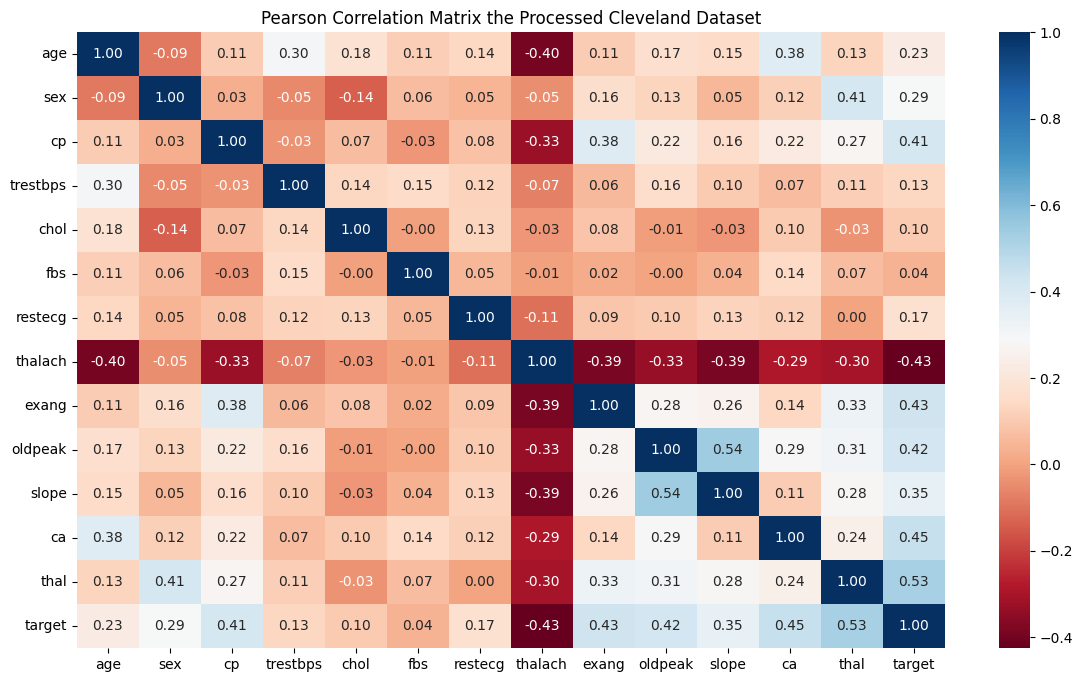

set()
Class distribution of Row Data: Counter({0: 161, 1: 134})
Class distribution after RO: Counter({1: 161, 0: 161})
Class distribution after TL: Counter({1: 134, 0: 133})
Class distribution after RO + TL: Counter({0: 161, 1: 139})


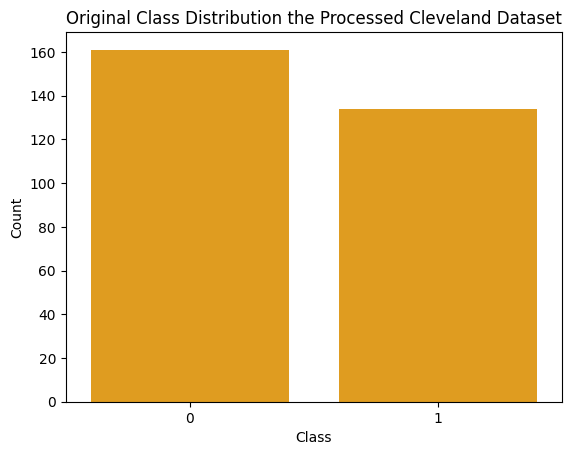

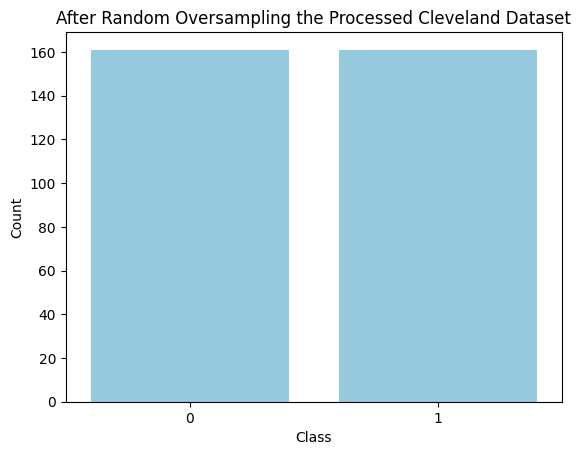

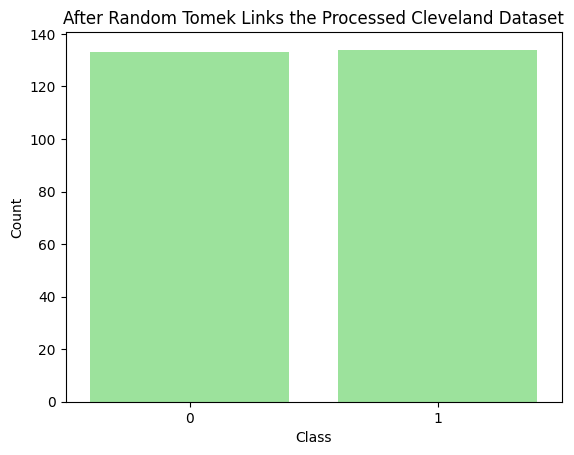

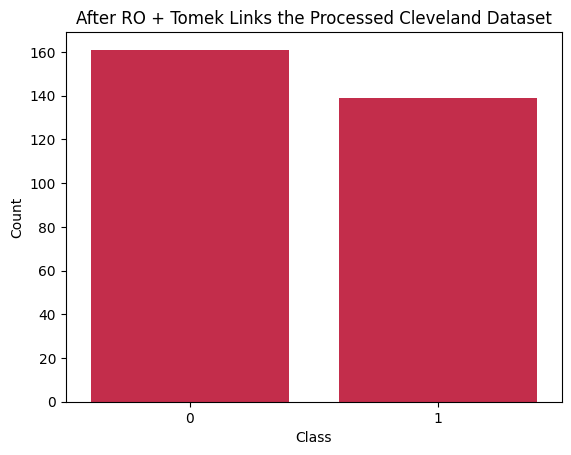

[LightGBM] [Info] Number of positive: 115, number of negative: 125
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000073 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 221
[LightGBM] [Info] Number of data points in the train set: 240, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.479167 -> initscore=-0.083382
[LightGBM] [Info] Start training from score -0.083382
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

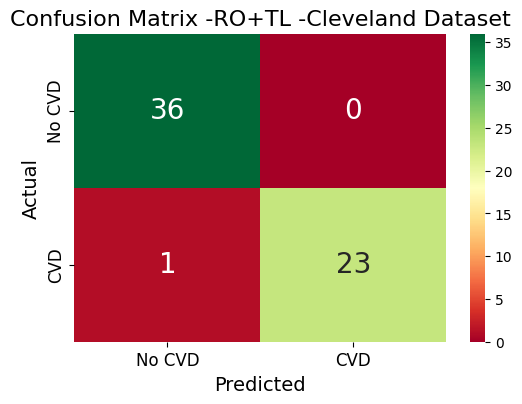

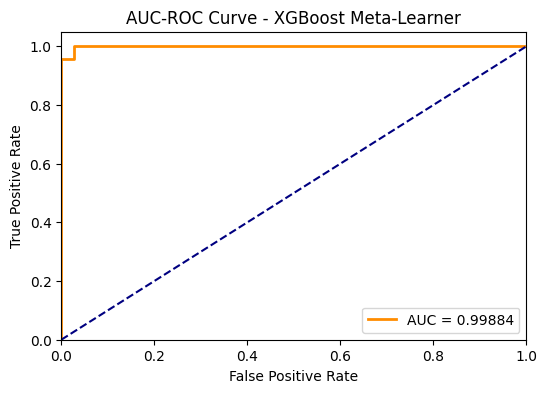

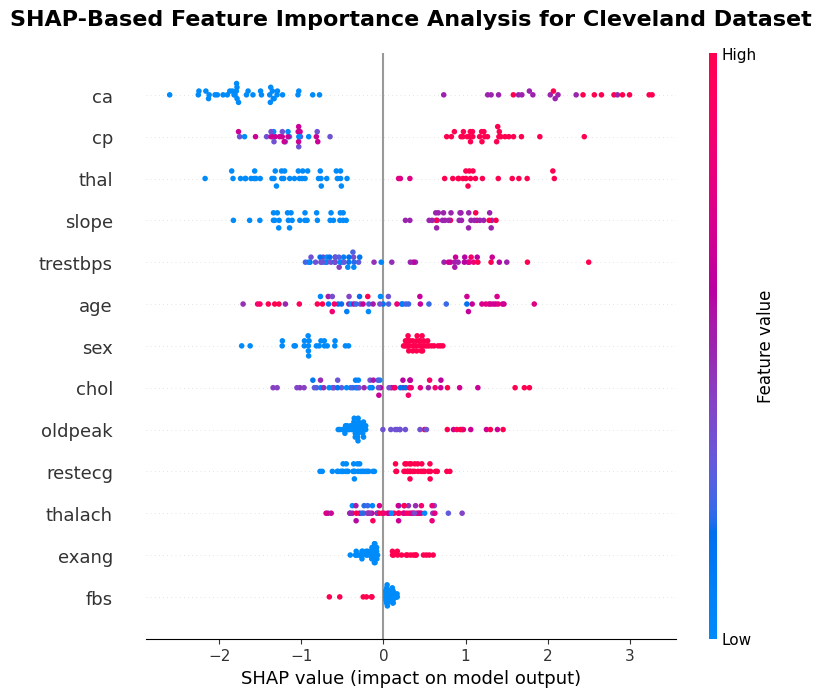

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load the heart disease dataset
dfc = pd.read_csv('/content/processed.cleveland.data')

#Rename male to Gender
dfc.columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang',
    'oldpeak', 'slope', 'ca', 'thal', 'target'
]

# Replace '?' with NaN
dfc = dfc.replace('?', np.nan)

# Convert all columns to numeric, coercing errors to NaN if conversion is not possible
for col in dfc.columns:
    dfc[col] = pd.to_numeric(dfc[col], errors='coerce')


# Calculate column-wise missing value counts
missing_counts = dfc.isnull().sum()
# Filter to show only columns with missing values
missing_counts = missing_counts[missing_counts > 0]
if not missing_counts.empty:
    print("Column-wise missing value counts in 'dfc' DataFrame:")
    display(missing_counts.sort_values(ascending=False))
else:
    print("No missing values found in 'dfc' DataFrame.")


def missing_values(data, thresh=1.5, width=8, height=4):

    percentage = (data.isnull().mean() * 100).sort_values(ascending=False)

    plt.figure(figsize=(width, height))

    percentage.plot.bar(
        color=sns.blend_palette(["red", "orange"], len(data.columns)),
        edgecolor='black'
    )

    plt.axhline(thresh, color='red', linestyle='--', linewidth=2)
    plt.ylim(0, max(percentage.max(), thresh) + 2)

    plt.title('Feature-wise Missing Value Analysis of the Processed Cleveland Dataset', fontweight='bold')
    plt.xlabel('Columns', fontweight='bold')
    plt.ylabel('Missing Values (%)', fontweight='bold')


    plt.text(len(percentage)*0.3, thresh+1,
             f'Columns with more than {thresh}% missing values', color='crimson')

    plt.text(len(percentage)*0.3, thresh-1,
             f'Columns with more than {thresh}% missing values', color='green')

    # Customize the font size of tick labels
    plt.xticks(rotation=90)
    plt.xticks(fontsize=7)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.savefig('Missing Value dfc',dpi=800, bbox_inches='tight')
    # Show the plot
    plt.show()

# Run
missing_values(dfc)

# Note: Mode imputation is often used for categorical variables.
mode_imputer = SimpleImputer(strategy='most_frequent')
df_mode_imputed = pd.DataFrame(mode_imputer.fit_transform(dfc), columns=dfc.columns)

dfc=df_mode_imputed

dfc_no=df.copy()
dfc['target'] = np.where(dfc['target'] >= 1, 1, dfc['target'])
dfc['target'] = dfc['target'].astype(int)


# Calculate column-wise missing value counts
missing_counts = dfc.isnull().sum()
# Filter to show only columns with missing values
missing_counts = missing_counts[missing_counts > 0]
if not missing_counts.empty:
    print("Column-wise missing value counts in 'dfc' DataFrame:")
    display(missing_counts.sort_values(ascending=False))
else:
    print("No missing values found in 'dfc' DataFrame.")



import seaborn as sns
import matplotlib.pyplot as plt
# Set figure size (width, height)
plt.figure(figsize=(8,4))  # Adjust the figure size as needed

# Create a boxplot
sns.boxplot(dfc[['trestbps', 'chol', 'thalach', 'oldpeak','fbs']])

# Set plot title and labels
plt.title('Box Plot of Continuous features of the Processed Cleveland Dataset before Outlier Removal', fontsize=10) # Changed title for clarity
plt.xlabel('Variable', fontsize=10)
plt.ylabel('Value', fontsize=10)

# Customize the font size of tick labels
plt.xticks(fontsize=7)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig('Box Plot dfc(Before)',dpi=800, bbox_inches='tight' ) # Changed filename for clarity
# Show the plot
plt.show()


# Creation of Z-scores for relevant numerical features
dfc['zscore_chol'] = ( dfc['chol'] - dfc['chol'].mean() ) / dfc['chol'].std()
dfc['zscore_trestbps'] = ( dfc['trestbps'] - dfc['trestbps'].mean() ) / dfc['trestbps'].std()
dfc['zscore_thalach'] = ( dfc['thalach'] - dfc['thalach'].mean() ) / dfc['thalach'].std()
dfc['zscore_fbs'] = ( dfc['fbs'] - dfc['fbs'].mean() ) / dfc['fbs'].std()

# Apply outlier removal based on a less strict Z-score threshold (e.g., -3 and 3)
dfc_temp = dfc[
    (dfc['zscore_chol'].between(-3, 3, inclusive='neither')) &
    (dfc['zscore_trestbps'].between(-3, 3, inclusive='neither')) &
    (dfc['zscore_thalach'].between(-3, 3, inclusive='neither')) &
    (dfc['zscore_fbs'].between(-3, 3, inclusive='neither'))
]

# Check if the temporary DataFrame is empty after outlier removal
if dfc_temp.empty:
    print("Warning: Outlier removal resulted in an empty DataFrame. Skipping outlier removal for these features.")
    pass # No change to dfc if empty after outlier removal to avoid unintended data loss
else:
    dfc = dfc_temp # Update dfc with the outlier-removed data

# Removed Z-score columns if they exist (only if outlier removal was applied and not reverted)
if 'zscore_chol' in dfc.columns:
    dfc.drop(columns=['zscore_chol', 'zscore_trestbps', 'zscore_thalach', 'zscore_fbs'], inplace=True)

# Convert remaining columns to integer type (as per original notebook's intent)
# Check if dfc is empty before converting, to avoid error if it still becomes empty
if not dfc.empty:
    dfc = dfc.astype(int)
else:
    print("Warning: DataFrame is empty even after attempting to restore. Cannot convert to int.")




import seaborn as sns
import matplotlib.pyplot as plt
# Set figure size (width, height)
plt.figure(figsize=(8,4))  # Adjust the figure size as needed

# Create a boxplot
sns.boxplot(dfc[['trestbps', 'chol', 'thalach', 'fbs']])

# Set plot title and labels
plt.title('Box Plot of Continuous features of the Processed Cleveland Dataset after Outlier Removal', fontsize=10) # Changed title for clarity
plt.xlabel('Variable', fontsize=10)
plt.ylabel('Value', fontsize=10)

# Customize the font size of tick labels
plt.xticks(fontsize=7)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig('Box Plot dfc(After)',dpi=800, bbox_inches='tight' ) # Changed filename for clarity
# Show the plot
plt.show()



#Correlation
import seaborn as sns
import matplotlib.pyplot as plt
correlation_matrix = dfc.corr(method='pearson')
plt.figure(figsize=(14, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu', fmt=".2f")
plt.title('Pearson Correlation Matrix the Processed Cleveland Dataset')
plt.savefig('Correlation dfc',dpi=800, bbox_inches='tight')
plt.show()
def correlation(dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr
corr_features = correlation(dfc, 0.8)
len(set(corr_features))
corr_features
print(corr_features)
dfc=dfc.drop(corr_features,axis=1)




# Random Oversampling (RO)

from imblearn.over_sampling import RandomOverSampler
from collections import Counter

X = dfc.drop(columns=['target'])  # Adjust 'target' to the actual name of the target column in  dataset
Y = dfc['target']
print("Class distribution of Row Data:", Counter(Y))
# Apply Random Oversampling
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, Y)
# Check new class distribution
print("Class distribution after RO:", Counter(y_resampled))
dfc1=pd.concat([X_resampled, y_resampled],axis=1)




 #Tomek Link (TL)

from imblearn.under_sampling import TomekLinks
from collections import Counter
# Apply Tomek Links undersampling
tl = TomekLinks()
X_resampled_t, y_resampled_t = tl.fit_resample(X, Y)
# Check new class distribution
print("Class distribution after TL:", Counter(y_resampled_t))
dfc2=pd.concat([X_resampled_t, y_resampled_t],axis=1)



#Combining Random Oversampling (RO) with Tomek Links (TL)

from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import TomekLinks
from collections import Counter
# Step 1: Apply Random Oversampling (RO)
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, Y)
# Step 2: Apply Tomek Links (TL) to clean overlapping samples
tl = TomekLinks()
X_final, y_final = tl.fit_resample(X_resampled, y_resampled)
# Check new class distribution
print("Class distribution after RO + TL:", Counter(y_final))
dfc3=pd.concat([X_final, y_final],axis=1)



import matplotlib.pyplot as plt
import seaborn as sns

# Plot class distribution
def plot_class_distribution(y, title, color='orange'):
    sns.countplot(x=y, color=color)
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.savefig('Class Distribution dfc',dpi=800, bbox_inches='tight')
    plt.show()

# Plot original, after RO, and after RO + TL
plot_class_distribution(Y, "Original Class Distribution the Processed Cleveland Dataset",color='orange')
plot_class_distribution(y_resampled, "After Random Oversampling the Processed Cleveland Dataset",color='skyblue' )
plot_class_distribution(y_resampled_t, "After Random Tomek Links the Processed Cleveland Dataset",color='lightgreen')
plot_class_distribution(y_final, "After RO + Tomek Links the Processed Cleveland Dataset",color='crimson')





#Model

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import ExtraTreesClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, auc, matthews_corrcoef, balanced_accuracy_score
)

#Model



#  Load Dataset (Assuming Preprocessed X_res, y_res)
#X,y = dfc.drop(columns=['target']), dfc['target']# RAW DATA
#X,y = dfc1.drop(columns=['target']), dfc1['target']# RO DATA
#X,y = dfc2.drop(columns=['target']), dfc2['target']# TL DATA
X,y = dfc3.drop(columns=['target']), dfc3['target']# RO+TL DATA
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#  Base Models
et_clf = ExtraTreesClassifier(n_estimators=100, random_state=42)
lgb_clf = LGBMClassifier(n_estimators=100, random_state=42)
cat_clf = CatBoostClassifier(iterations=100, random_state=42, verbose=0)

#  Train Base Models
et_clf.fit(X_train, y_train)
lgb_clf.fit(X_train, y_train)
cat_clf.fit(X_train, y_train)

#  Generate Predictions from Base Models
et_pred = et_clf.predict_proba(X_test)[:, 1]
lgb_pred = lgb_clf.predict_proba(X_test)[:, 1]
cat_pred = cat_clf.predict_proba(X_test)[:, 1]

#  Stack Predictions as Features for Meta-Learner
meta_features = np.column_stack((et_pred, lgb_pred, cat_pred))

#  Meta-Learner (XGBoost)
xgb_meta = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_meta.fit(meta_features, y_test)

#  Final Test Predictions
meta_pred = xgb_meta.predict(meta_features)
meta_proba = xgb_meta.predict_proba(meta_features)[:, 1]

#  Confusion Matrix
cm = confusion_matrix(y_test, meta_pred)
tn, fp, fn, tp = cm.ravel()

#  Compute Metrics
accuracy = accuracy_score(y_test, meta_pred)
precision = precision_score(y_test, meta_pred)
recall = recall_score(y_test, meta_pred)
f1 = f1_score(y_test, meta_pred)
specificity = tn / (tn + fp)
mcc = matthews_corrcoef(y_test, meta_pred)
balanced_acc = balanced_accuracy_score(y_test, meta_pred)
roc_auc = roc_auc_score(y_test, meta_proba)

#  Print Evaluation Metrics
print(" Stacking Ensemble with XGBoost Meta-Learner")
print(" Accuracy:", accuracy)
print(" Precision:", precision)
print(" Recall (Sensitivity):", recall)
print(" F1 Score:", f1)
print(" Specificity:", specificity)
print(" Matthews Correlation Coefficient (MCC):", mcc)
print(" Balanced Accuracy:", balanced_acc)
print(" ROC-AUC:", roc_auc)



#  Confusion Matrix Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="RdYlGn",annot_kws={"size": 20}, xticklabels=['No CVD', 'CVD'], yticklabels=['No CVD', 'CVD'])
plt.xlabel("Predicted",fontsize=14)
plt.ylabel("Actual",fontsize=14)
plt.title("Confusion Matrix -RO+TL -Cleveland Dataset",fontsize=16)
plt.savefig('Confusion Matrix_Cleveland Dataset',dpi=800, bbox_inches='tight')
# Increase tick label font size
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()




#  AUC-ROC Curve
fpr, tpr, _ = roc_curve(y_test, meta_proba)
roc_auc_value = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color="darkorange", lw=2, label="AUC = {:.5f}".format(roc_auc_value))
plt.plot([0, 1], [0, 1], color="navy", linestyle="--")  # Random classifier baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AUC-ROC Curve - XGBoost Meta-Learner")
plt.legend(loc="lower right")
plt.show()


import shap
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

# Train XGBoost model
xgb_clf = XGBClassifier(random_state=42)
xgb_clf.fit(X_train, y_train)

# SHAP explanation
explainer = shap.TreeExplainer(xgb_clf)
shap_values = explainer.shap_values(X_test)

# Create SHAP summary plot
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_test, show=False)

# Add title
plt.title("SHAP-Based Feature Importance Analysis for Cleveland Dataset",
          fontsize=16, fontweight='bold', pad=20)

# Save figure
plt.savefig("SHAP_Cleveland_Dataset.png",
            dpi=300,
            bbox_inches="tight")

# Display plot
plt.show()

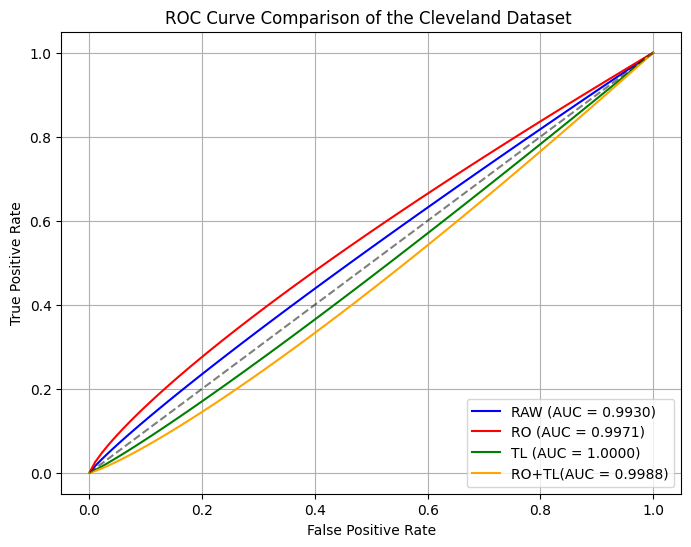

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Simulated FPR and TPR values for three models
fpr1, tpr1 = np.linspace(0, 1, 100), np.linspace(0, 1, 100) ** 0.9  # Model 1
fpr2, tpr2 = np.linspace(0, 1, 100), np.linspace(0, 1, 100) ** 0.8  # Model 2
fpr3, tpr3 = np.linspace(0, 1, 100), np.linspace(0, 1, 100) ** 1.1  # Model 3
fpr4, tpr4 = np.linspace(0, 1, 100), np.linspace(0, 1, 100) ** 1.2  # Model 4

# AUC values
auc1, auc2, auc3 ,auc4= 0.9930,0.9971,1.00,0.9988

# Plot ROC Curves
plt.figure(figsize=(8, 6))
plt.plot(fpr1, tpr1, label=f'RAW (AUC = {auc1:.4f})', color='blue')
plt.plot(fpr2, tpr2, label=f'RO (AUC = {auc2:.4f})', color='red')
plt.plot(fpr3, tpr3, label=f'TL (AUC = {auc3:.4f})', color='green')
plt.plot(fpr4, tpr4, label=f'RO+TL(AUC = {auc4:.4f})', color='orange')

# Random classifier line
plt.plot([0, 1], [0, 1], linestyle='--', color='black', alpha=0.5)

# Labels and Legend
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison of the Cleveland Dataset ')
plt.legend(loc='lower right')
plt.grid()

# Show the plot
plt.show()


#Feature-wise Analysis of the Processed Hungarian Dataset

In [ ]:
dfh = pd.read_csv('/content/processed.hungarian.data')

In [ ]:
dfh

,28,1,2,130,132,0,2.1,185,0.1,0.2,?,?.1,?.2,0.3
0,29,1,2,120,243,0,0,160,0,0.0,?,?,?,0
1,29,1,2,140,?,0,0,170,0,0.0,?,?,?,0
2,30,0,1,170,237,0,1,170,0,0.0,?,?,6,0
3,31,0,2,100,219,0,1,150,0,0.0,?,?,?,0
4,32,0,2,105,198,0,0,165,0,0.0,?,?,?,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
288,52,1,4,160,331,0,0,94,1,2.5,?,?,?,1
289,54,0,3,130,294,0,1,100,1,0.0,2,?,?,1
290,56,1,4,155,342,1,0,150,1,3.0,2,?,?,1
291,58,0,2,180,393,0,0,110,1,1.0,2,?,7,1


In [ ]:
#value for target column
dfh['0.3'].value_counts()

,count
0.3,
0,187
1,106


Column-wise missing value counts in 'dfh' DataFrame:


,0
ca,290
thal,265
slope,189
chol,23
fbs,8
trestbps,1
restecg,1
thalach,1
exang,1


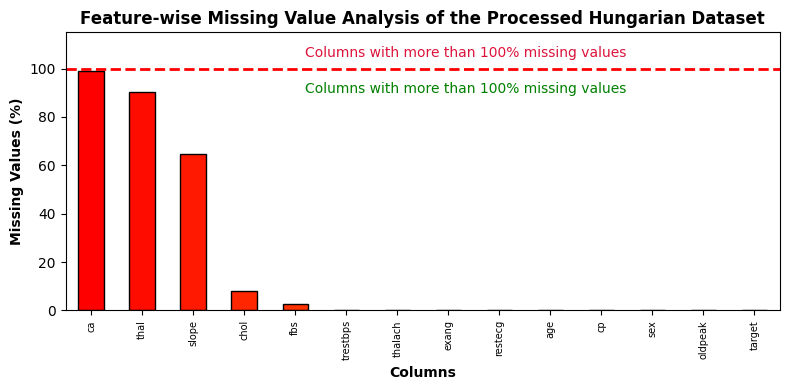

No missing values found in 'dfh' DataFrame.


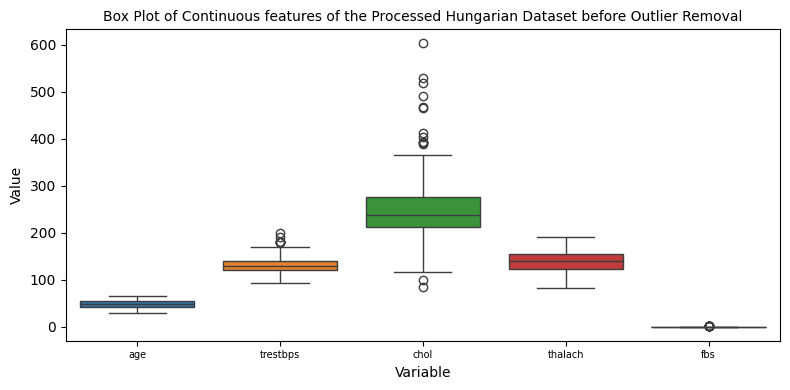

/tmp/ipykernel_491/488218622.py:131: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfh.drop(columns=['zscore_chol', 'zscore_trestbps', 'zscore_thalach', 'zscore_fbs'], inplace=True)


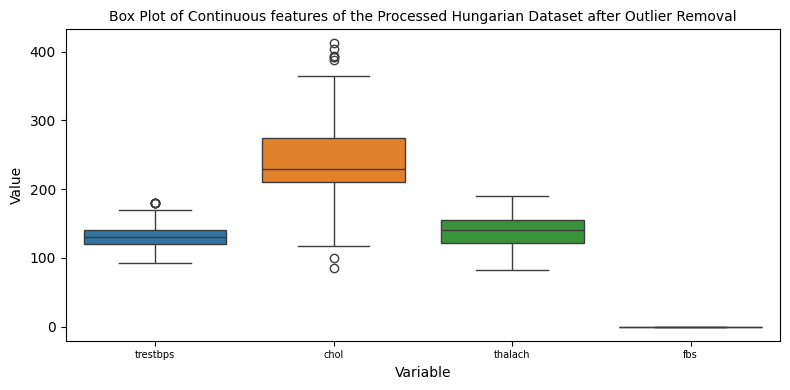

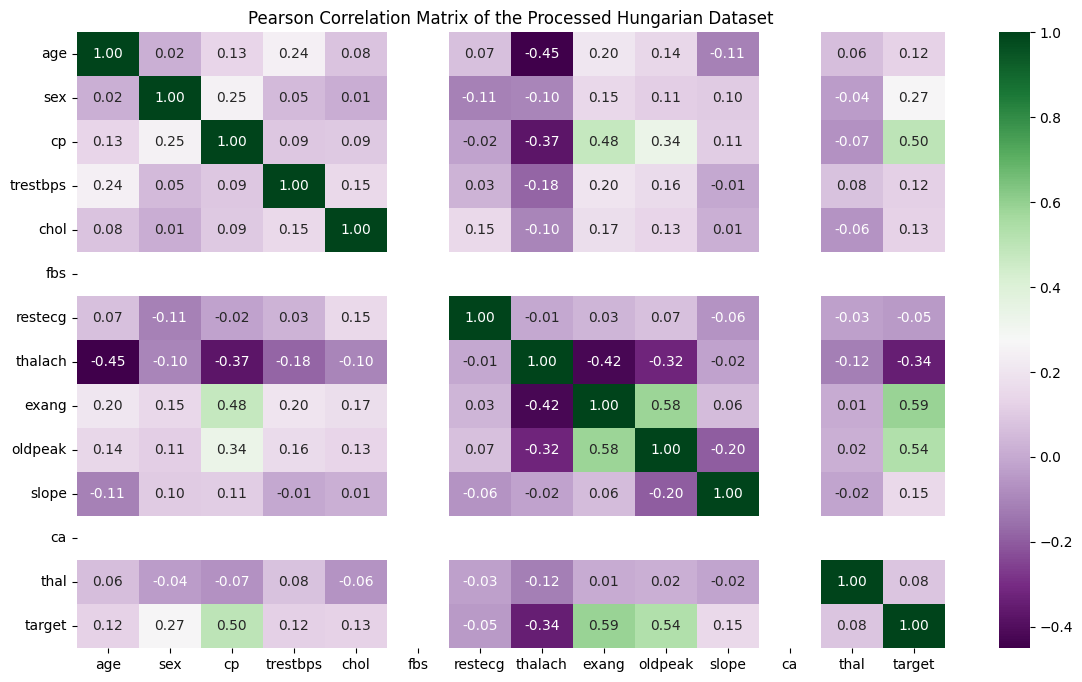

set()
Class distribution of Row Data: Counter({0: 178, 1: 88})
Class distribution after RO: Counter({0: 178, 1: 178})
Class distribution after TL: Counter({0: 158, 1: 88})
Class distribution after RO + TL: Counter({0: 178, 1: 171})


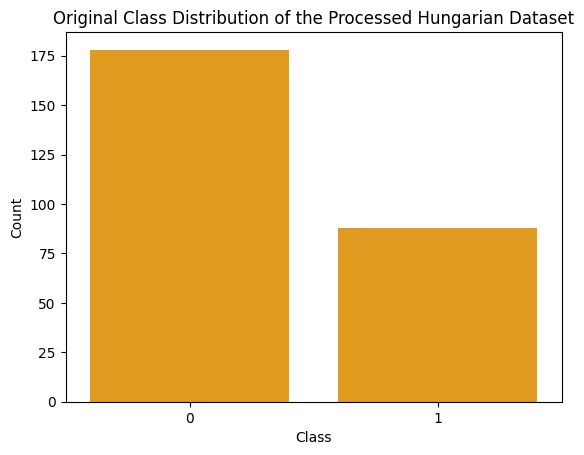

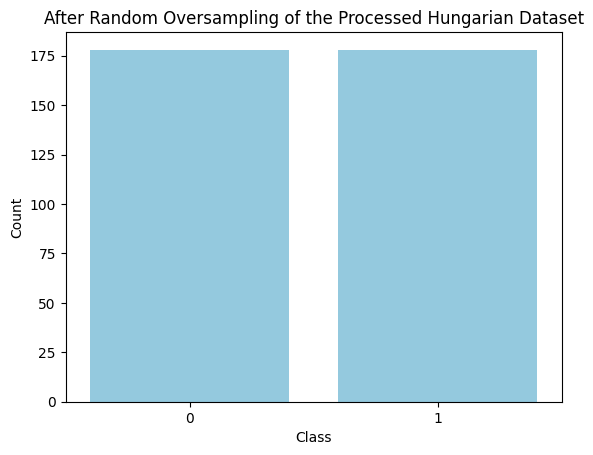

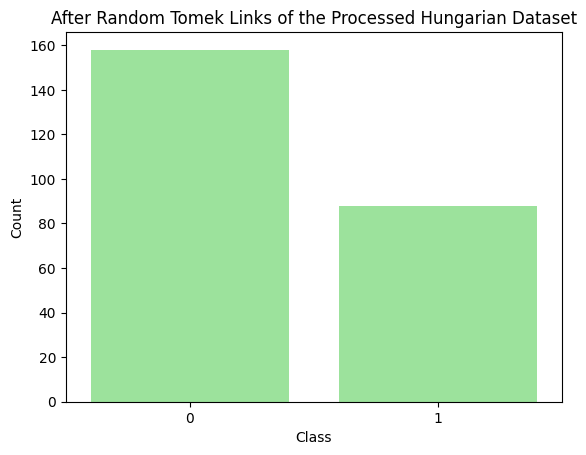

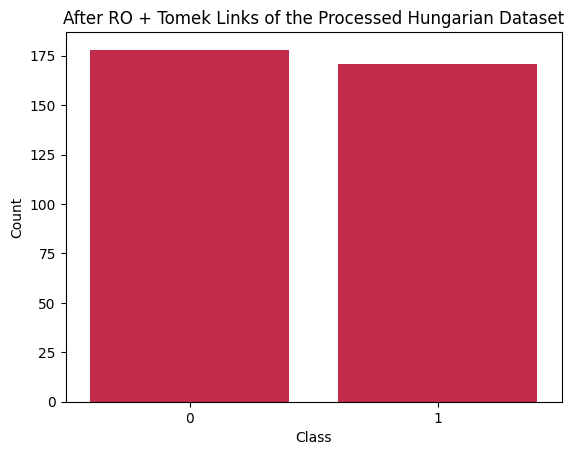

[LightGBM] [Info] Number of positive: 140, number of negative: 139
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000099 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 180
[LightGBM] [Info] Number of data points in the train set: 279, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.501792 -> initscore=0.007168
[LightGBM] [Info] Start training from score 0.007168
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

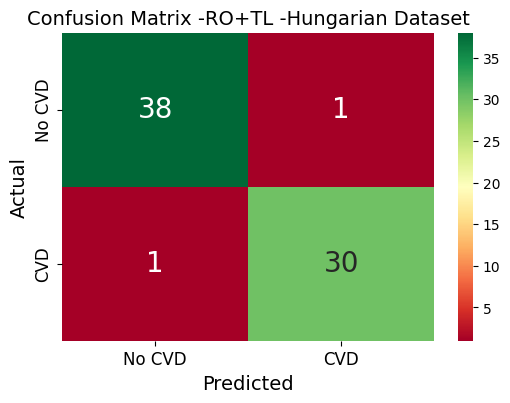

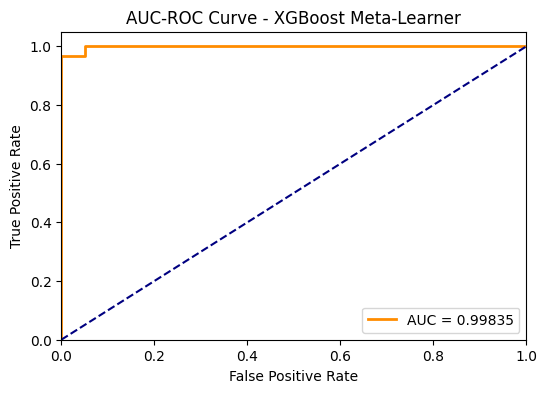

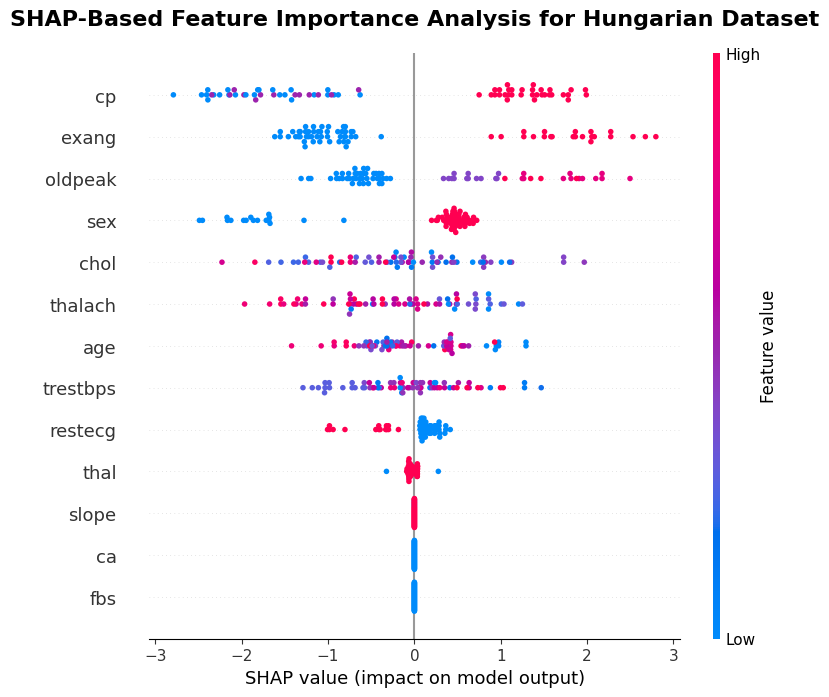

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load the heart disease dataset
dfh = pd.read_csv('/content/processed.hungarian.data')

#Rename male to Gender

dfh.columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang',
    'oldpeak', 'slope', 'ca', 'thal', 'target'
]
# Replace '?' with NaN
dfh = dfh.replace('?', np.nan)

# Convert all columns to numeric, coercing errors to NaN if conversion is not possible
for col in dfh.columns:
    dfh[col] = pd.to_numeric(dfh[col], errors='coerce')

# Calculate column-wise missing value counts
missing_counts = dfh.isnull().sum()
# Filter to show only columns with missing values
missing_counts = missing_counts[missing_counts > 0]
if not missing_counts.empty:
    print("Column-wise missing value counts in 'dfh' DataFrame:")
    display(missing_counts.sort_values(ascending=False))
else:
    print("No missing values found in 'dfh' DataFrame.")



def missing_values(data, thresh=100, width=8, height=4):

    percentage = (data.isnull().mean() * 100).sort_values(ascending=False)

    plt.figure(figsize=(width, height))

    percentage.plot.bar(
        color=sns.blend_palette(["red", "orange"], len(data.columns)),
        edgecolor='black'
    )

    plt.axhline(thresh, color='red', linestyle='--', linewidth=2)
    plt.ylim(0, max(percentage.max(), thresh) + 15)

    plt.title('Feature-wise Missing Value Analysis of the Processed Hungarian Dataset', fontweight='bold')
    plt.xlabel('Columns', fontweight='bold')
    plt.ylabel('Missing Values (%)', fontweight='bold')


    plt.text(len(percentage)*0.3, thresh+5,
             f'Columns with more than {thresh}% missing values', color='crimson')

    plt.text(len(percentage)*0.3, thresh-10,
             f'Columns with more than {thresh}% missing values', color='green')

    # Customize the font size of tick labels
    plt.xticks(rotation=90)
    plt.xticks(fontsize=7)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.savefig('Missing Value dfh',dpi=800, bbox_inches='tight')
    # Show the plot
    plt.show()

# Run
missing_values(dfh)


# Note: Mode imputation is often used for categorical variables.
mode_imputer = SimpleImputer(strategy='most_frequent')
df_mode_imputed = pd.DataFrame(mode_imputer.fit_transform(dfh), columns=dfh.columns)

dfh=df_mode_imputed

dfh_no=df.copy()


# Calculate column-wise missing value counts
missing_counts = dfh.isnull().sum()
# Filter to show only columns with missing values
missing_counts = missing_counts[missing_counts > 0]
if not missing_counts.empty:
    print("Column-wise missing value counts in 'dfh' DataFrame:")
    display(missing_counts.sort_values(ascending=False))
else:
    print("No missing values found in 'dfh' DataFrame.")



import seaborn as sns
import matplotlib.pyplot as plt
# Set figure size (width, height)
plt.figure(figsize=(8,4))  # Adjust the figure size as needed

# Create a boxplot
sns.boxplot(dfh[['age', 'trestbps', 'chol', 'thalach', 'fbs']])

# Set plot title and labels
plt.title('Box Plot of Continuous features of the Processed Hungarian Dataset before Outlier Removal', fontsize=10) # Changed title for clarity
plt.xlabel('Variable', fontsize=10)
plt.ylabel('Value', fontsize=10)

# Customize the font size of tick labels
plt.xticks(fontsize=7)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig('Box Plot dfh(before)',dpi=800,bbox_inches="tight" ) # Changed filename for clarity
# Show the plot
plt.show()



# Outlier detection and removal using Z-score

# Creation of Z-scores for relevant numerical features
dfh['zscore_chol'] = ( dfh['chol'] - dfh['chol'].mean() ) / dfh['chol'].std()
dfh['zscore_trestbps'] = ( dfh['trestbps'] - dfh['trestbps'].mean() ) / dfh['trestbps'].std()
dfh['zscore_thalach'] = ( dfh['thalach'] - dfh['thalach'].mean() ) / dfh['thalach'].std()
dfh['zscore_fbs'] = ( dfh['fbs'] - dfh['fbs'].mean() ) / dfh['fbs'].std()

# Outlier removal based on Z-score threshold of -3 and 3
dfh = dfh[
    (dfh['zscore_chol'] > -3) & (dfh['zscore_chol'] < 3) &
    (dfh['zscore_trestbps'] > -3) & (dfh['zscore_trestbps'] < 3) &
    (dfh['zscore_thalach'] > -3) & (dfh['zscore_thalach'] < 3) &
    (dfh['zscore_fbs'] > -3) & (dfh['zscore_fbs'] < 3)
]

# Removed Z-score columns
dfh.drop(columns=['zscore_chol', 'zscore_trestbps', 'zscore_thalach', 'zscore_fbs'], inplace=True)

# Convert remaining columns to integer type (as per original notebook's intent)
dfh = dfh.astype(int)


#Box plot

# Set figure size (width, height)
plt.figure(figsize=(8,4))  # Adjust the figure size as needed

# Create a boxplot
sns.boxplot(dfh[[ 'trestbps', 'chol', 'thalach', 'fbs']])

# Set plot title and labels
plt.title('Box Plot of Continuous features of the Processed Hungarian Dataset after Outlier Removal', fontsize=10) # Changed title for clarity
plt.xlabel('Variable', fontsize=10)
plt.ylabel('Value', fontsize=10)

# Customize the font size of tick labels
plt.xticks(fontsize=7)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig('Box Plot dfh(After)',dpi=800,bbox_inches="tight" ) # Changed filename for clarity
# Show the plot
plt.show()






#Correlation
import seaborn as sns
import matplotlib.pyplot as plt
# Calculate Pearson correlation matrix for all numerical features
correlation_matrix = dfh.corr(method='pearson')
#correlation_matrix = df.corr(method='spearman')
#heatmap
#print(correlation_matrix)
# Visualize the correlation matrix
plt.figure(figsize=(14, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='PRGn', fmt=".2f")
plt.title('Pearson Correlation Matrix of the Processed Hungarian Dataset')
plt.savefig('Correlation dfh',dpi=800, bbox_inches='tight')
#plt.title('Spearman Correlation Matrix')
plt.show()
# with the following function we can select highly correlated features
# it will remove the first feature that is correlated with anything other feature

def correlation(dataset, threshold):
    col_corr = set()  # Set of all the names of correlated columns
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold: # we are interested in absolute coeff value
                colname = corr_matrix.columns[i]  # getting the name of column
                col_corr.add(colname)
    return col_corr
#find out features
corr_features = correlation(dfh, 0.8)
len(set(corr_features))
corr_features
print(corr_features)
dfh=dfh.drop(corr_features,axis=1)




# Random Oversampling (RO)

from imblearn.over_sampling import RandomOverSampler
from collections import Counter

X = dfh.drop(columns=['target'])  # Adjust 'target' to the actual name of the target column in  dataset
Y = dfh['target']
print("Class distribution of Row Data:", Counter(Y))
# Apply Random Oversampling
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, Y)
# Check new class distribution
print("Class distribution after RO:", Counter(y_resampled))
dfh1=pd.concat([X_resampled, y_resampled],axis=1)




 #Tomek Link (TL)

from imblearn.under_sampling import TomekLinks
from collections import Counter
# Apply Tomek Links undersampling
tl = TomekLinks()
X_resampled_t, y_resampled_t = tl.fit_resample(X, Y)
# Check new class distribution
print("Class distribution after TL:", Counter(y_resampled_t))
dfh2=pd.concat([X_resampled_t, y_resampled_t],axis=1)



#Combining Random Oversampling (RO) with Tomek Links (TL)

from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import TomekLinks
from collections import Counter
# Step 1: Apply Random Oversampling (RO)
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, Y)
# Step 2: Apply Tomek Links (TL) to clean overlapping samples
tl = TomekLinks()
X_final, y_final = tl.fit_resample(X_resampled, y_resampled)
# Check new class distribution
print("Class distribution after RO + TL:", Counter(y_final))
dfh3=pd.concat([X_final, y_final],axis=1)



import matplotlib.pyplot as plt
import seaborn as sns

# Plot class distribution
def plot_class_distribution(y, title, color='orange'):
    sns.countplot(x=y, color=color)
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.savefig('Class Distribution dfh',dpi=800, bbox_inches='tight')
    plt.show()

# Plot original, after RO, and after RO + TL
plot_class_distribution(Y, "Original Class Distribution of the Processed Hungarian Dataset",color='orange')
plot_class_distribution(y_resampled, "After Random Oversampling of the Processed Hungarian Dataset",color='skyblue' )
plot_class_distribution(y_resampled_t, "After Random Tomek Links of the Processed Hungarian Dataset",color='lightgreen')
plot_class_distribution(y_final, "After RO + Tomek Links of the Processed Hungarian Dataset",color='crimson')





#MODEL



import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import ExtraTreesClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, auc, matthews_corrcoef, balanced_accuracy_score
)

#  Load Dataset (Assuming Preprocessed X_res, y_res)
#X,y = dfh.drop(columns=['target']), dfh['target']#RAW
#X,y = dfh1.drop(columns=['target']), dfh1['target']#RO
#X,y = dfh2.drop(columns=['target']), dfh2['target']#TL
X,y = dfh3.drop(columns=['target']), dfh3['target']#RO+TL
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#  Base Models
et_clf = ExtraTreesClassifier(n_estimators=100, random_state=42)
lgb_clf = LGBMClassifier(n_estimators=100, random_state=42)
cat_clf = CatBoostClassifier(iterations=100, random_state=42, verbose=0)

#  Train Base Models
et_clf.fit(X_train, y_train)
lgb_clf.fit(X_train, y_train)
cat_clf.fit(X_train, y_train)

#  Generate Predictions from Base Models
et_pred = et_clf.predict_proba(X_test)[:, 1]
lgb_pred = lgb_clf.predict_proba(X_test)[:, 1]
cat_pred = cat_clf.predict_proba(X_test)[:, 1]

#  Stack Predictions as Features for Meta-Learner
meta_features = np.column_stack((et_pred, lgb_pred, cat_pred))

#  Meta-Learner (XGBoost)
xgb_meta = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_meta.fit(meta_features, y_test)

#  Final Test Predictions
meta_pred = xgb_meta.predict(meta_features)
meta_proba = xgb_meta.predict_proba(meta_features)[:, 1]

#  Confusion Matrix
cm = confusion_matrix(y_test, meta_pred)
tn, fp, fn, tp = cm.ravel()

#  Compute Metrics
accuracy = accuracy_score(y_test, meta_pred)
precision = precision_score(y_test, meta_pred)
recall = recall_score(y_test, meta_pred)
f1 = f1_score(y_test, meta_pred)
specificity = tn / (tn + fp)
mcc = matthews_corrcoef(y_test, meta_pred)
balanced_acc = balanced_accuracy_score(y_test, meta_pred)
roc_auc = roc_auc_score(y_test, meta_proba)

#  Print Evaluation Metrics
print(" Stacking Ensemble with XGBoost Meta-Learner")
print(" Accuracy:", accuracy)
print(" Precision:", precision)
print(" Recall (Sensitivity):", recall)
print(" F1 Score:", f1)
print(" Specificity:", specificity)
print(" Matthews Correlation Coefficient (MCC):", mcc)
print(" Balanced Accuracy:", balanced_acc)
print(" ROC-AUC:", roc_auc)



#  Confusion Matrix Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="RdYlGn",annot_kws={"size": 20}, xticklabels=['No CVD', 'CVD'], yticklabels=['No CVD', 'CVD'])
plt.xlabel("Predicted",fontsize=14)
plt.ylabel("Actual",fontsize=14)
plt.title("Confusion Matrix -RO+TL -Hungarian Dataset",fontsize=14)
plt.savefig('Confusion Matrix dfh',dpi=800, bbox_inches='tight')
# Increase tick label font size
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()



#  AUC-ROC Curve
fpr, tpr, _ = roc_curve(y_test, meta_proba)
roc_auc_value = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color="darkorange", lw=2, label="AUC = {:.5f}".format(roc_auc_value))
plt.plot([0, 1], [0, 1], color="navy", linestyle="--")  # Random classifier baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AUC-ROC Curve - XGBoost Meta-Learner")
plt.legend(loc="lower right")
plt.show()


import shap
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

# Train XGBoost model
xgb_clf = XGBClassifier(random_state=42)
xgb_clf.fit(X_train, y_train)

# SHAP explanation
explainer = shap.TreeExplainer(xgb_clf)
shap_values = explainer.shap_values(X_test)

# Create SHAP summary plot
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_test, show=False)

# Add title
plt.title("SHAP-Based Feature Importance Analysis for Hungarian Dataset",
          fontsize=16, fontweight='bold', pad=20)

# Save figure
plt.savefig("SHAP_Hungarian_Dataset.png",
            dpi=300,
            bbox_inches="tight")

# Display plot
plt.show()

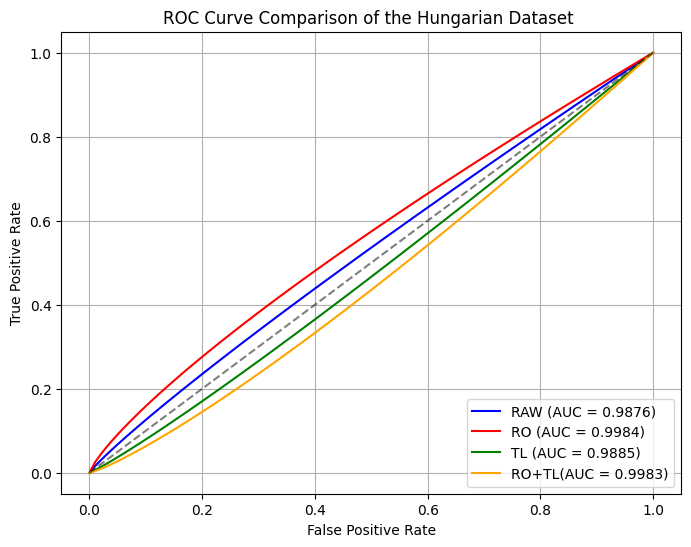

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Simulated FPR and TPR values for three models
fpr1, tpr1 = np.linspace(0, 1, 100), np.linspace(0, 1, 100) ** 0.9  # Model 1
fpr2, tpr2 = np.linspace(0, 1, 100), np.linspace(0, 1, 100) ** 0.8  # Model 2
fpr3, tpr3 = np.linspace(0, 1, 100), np.linspace(0, 1, 100) ** 1.1  # Model 3
fpr4, tpr4 = np.linspace(0, 1, 100), np.linspace(0, 1, 100) ** 1.2  # Model 4

# AUC values
auc1, auc2, auc3 ,auc4= 0.9876,0.9984,0.9885,0.9983

# Plot ROC Curves
plt.figure(figsize=(8, 6))
plt.plot(fpr1, tpr1, label=f'RAW (AUC = {auc1:.4f})', color='blue')
plt.plot(fpr2, tpr2, label=f'RO (AUC = {auc2:.4f})', color='red')
plt.plot(fpr3, tpr3, label=f'TL (AUC = {auc3:.4f})', color='green')
plt.plot(fpr4, tpr4, label=f'RO+TL(AUC = {auc4:.4f})', color='orange')

# Random classifier line
plt.plot([0, 1], [0, 1], linestyle='--', color='black', alpha=0.5)

# Labels and Legend
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison of the Hungarian Dataset ')
plt.legend(loc='lower right')
plt.grid()

# Show the plot
plt.show()



#Feature-wise  Analysis of the Processed Switzerland Dataset


In [ ]:
dfs = pd.read_csv('/content/processed.switzerland.data')

In [ ]:
dfs

,32,1,1.1,95,0,?,0.1,127,0.2,.7,1.2,?.1,?.2,1.3
0,34,1,4,115,0,?,?,154,0,.2,1,?,?,1
1,35,1,4,?,0,?,0,130,1,?,?,?,7,3
2,36,1,4,110,0,?,0,125,1,1,2,?,6,1
3,38,0,4,105,0,?,0,166,0,2.8,1,?,?,2
4,38,0,4,110,0,0,0,156,0,0,2,?,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,70,1,4,115,0,0,1,92,1,0,2,?,7,1
118,70,1,4,140,0,1,0,157,1,2,2,?,7,3
119,72,1,3,160,0,?,2,114,0,1.6,2,2,?,0
120,73,0,3,160,0,0,1,121,0,0,1,?,3,1


In [ ]:
#value for last column
dfs['1.3'].value_counts()

,count
1.3,
1,47
2,32
3,30
0,8
4,5


Column-wise missing value counts in 'dfs' DataFrame:


,0
ca,117
fbs,74
thal,51
slope,17
oldpeak,6
trestbps,2
exang,1
restecg,1
thalach,1


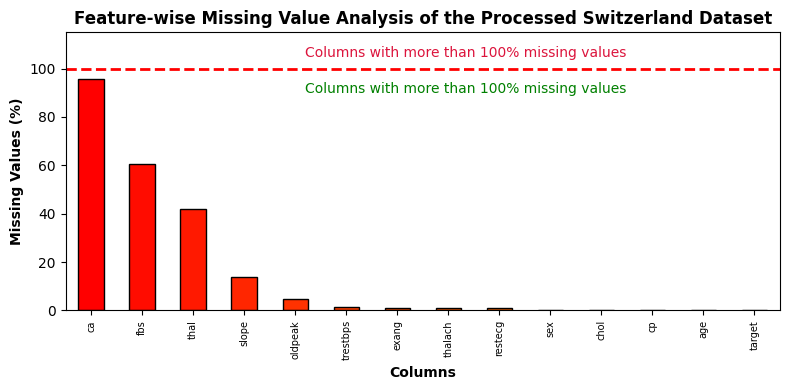

No missing values found in 'dfs' DataFrame.


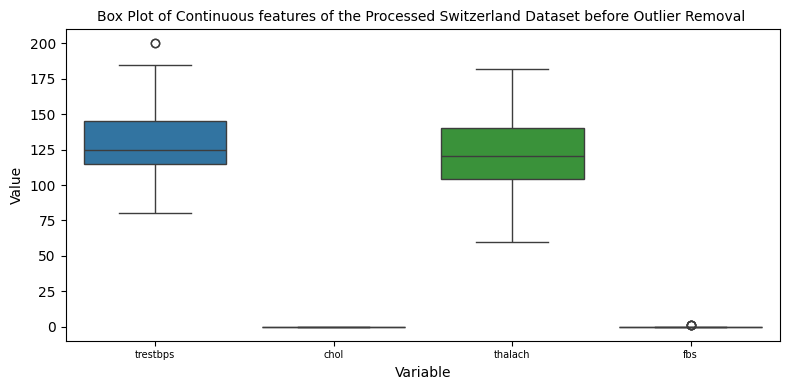

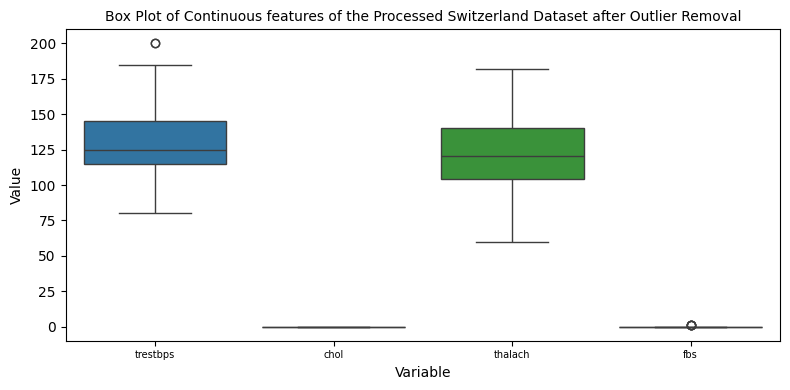

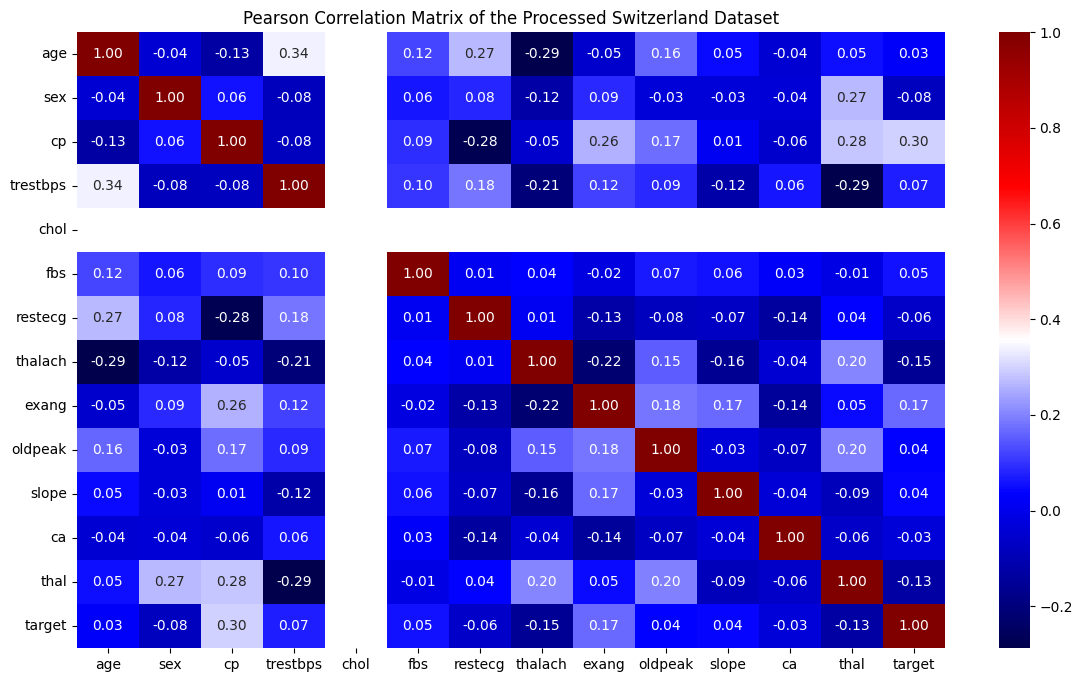

set()
Class distribution of Row Data: Counter({1: 114, 0: 8})
Class distribution after RO: Counter({1: 114, 0: 114})
Class distribution after TL: Counter({1: 110, 0: 8})
Class distribution after RO + TL: Counter({1: 114, 0: 114})


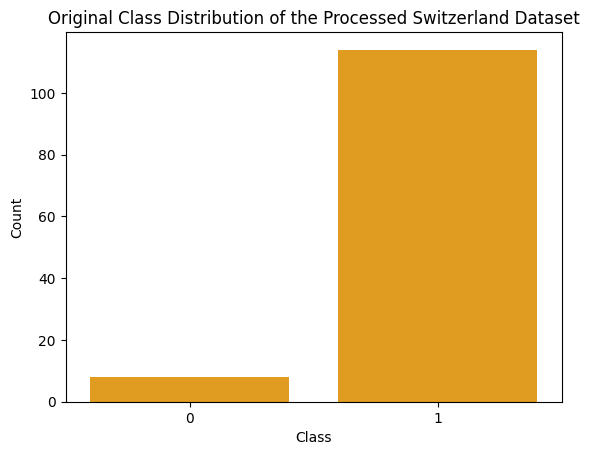

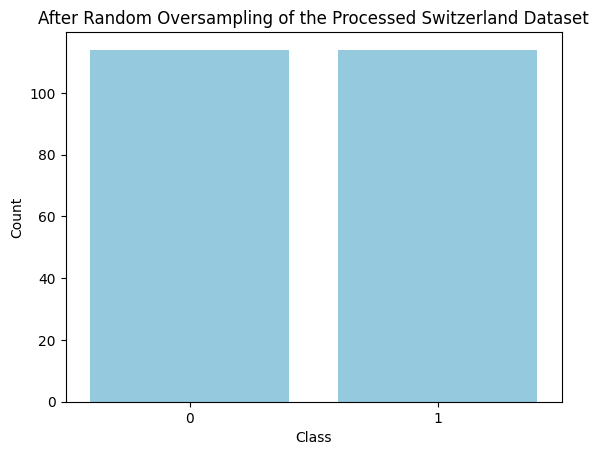

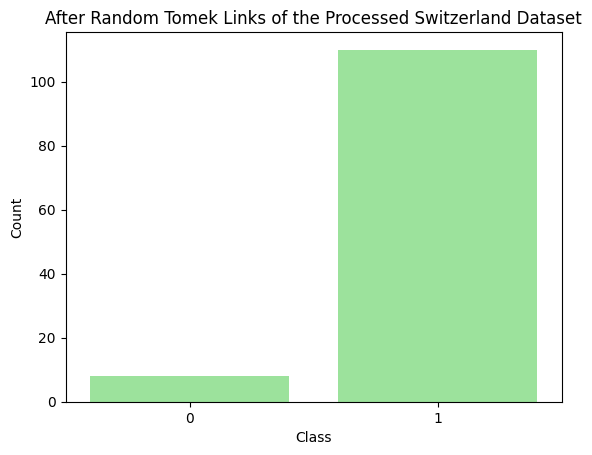

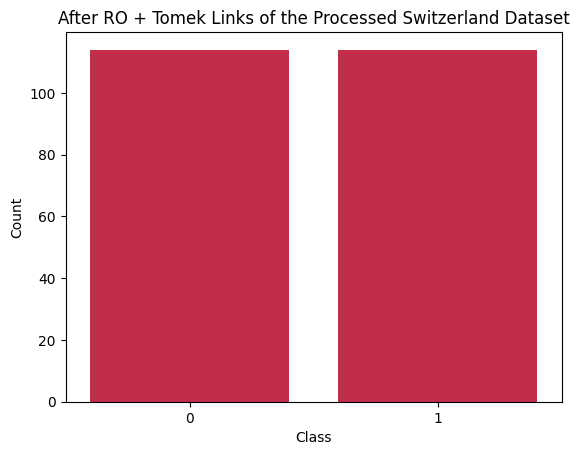

[LightGBM] [Info] Number of positive: 95, number of negative: 87
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000059 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 96
[LightGBM] [Info] Number of data points in the train set: 182, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.521978 -> initscore=0.087969
[LightGBM] [Info] Start training from score 0.087969
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Ligh

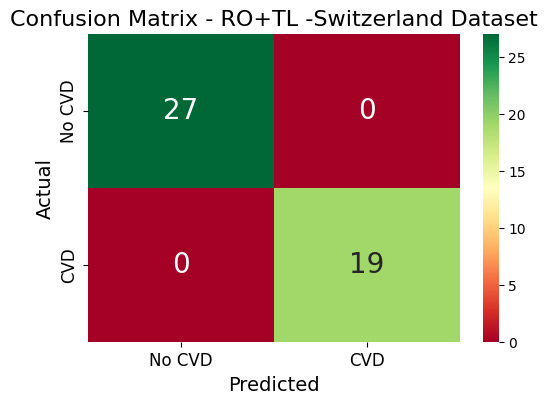

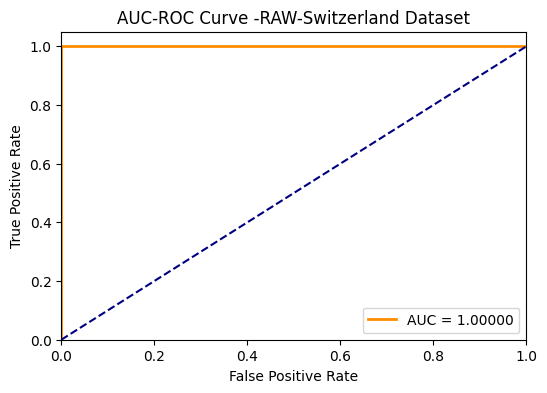

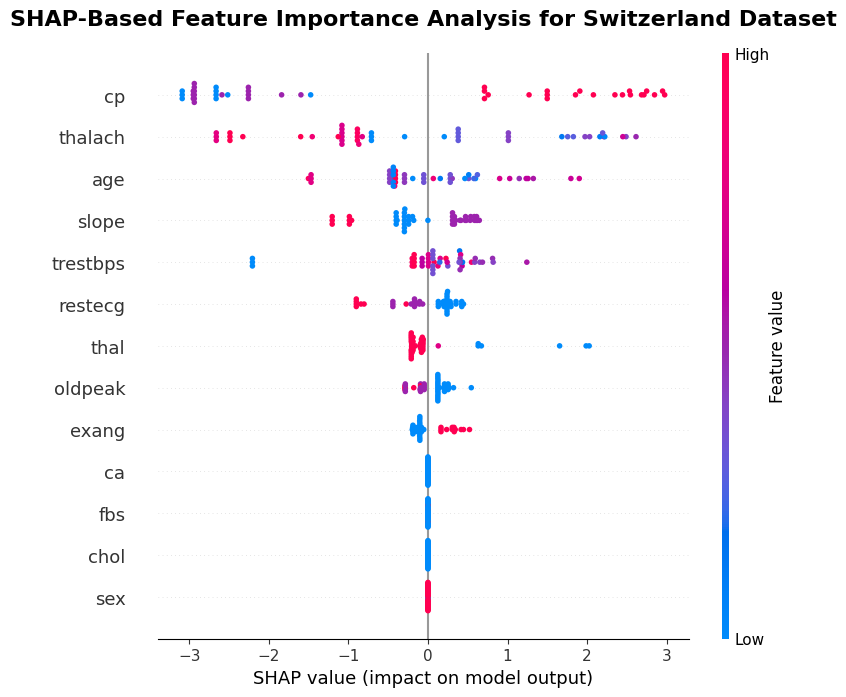

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load the heart disease dataset
dfs = pd.read_csv('/content/processed.switzerland.data')

#Rename male to Gender
dfs.columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang',
    'oldpeak', 'slope', 'ca', 'thal', 'target'
]
# Replace '?' with NaN
dfs = dfs.replace('?', np.nan)

# Convert all columns to numeric, coercing errors to NaN if conversion is not possible
for col in dfs.columns:
    dfs[col] = pd.to_numeric(dfs[col], errors='coerce')


# Calculate column-wise missing value counts
missing_counts = dfs.isnull().sum()
# Filter to show only columns with missing values
missing_counts = missing_counts[missing_counts > 0]
if not missing_counts.empty:
    print("Column-wise missing value counts in 'dfs' DataFrame:")
    display(missing_counts.sort_values(ascending=False))
else:
    print("No missing values found in 'dfs' DataFrame.")


def missing_values(data, thresh=100, width=8, height=4):

    percentage = (data.isnull().mean() * 100).sort_values(ascending=False)

    plt.figure(figsize=(width, height))

    percentage.plot.bar(
        color=sns.blend_palette(["red", "orange"], len(data.columns)),
        edgecolor='black'
    )

    plt.axhline(thresh, color='red', linestyle='--', linewidth=2)
    plt.ylim(0, max(percentage.max(), thresh) + 15)

    plt.title('Feature-wise Missing Value Analysis of the Processed Switzerland Dataset', fontweight='bold')
    plt.xlabel('Columns', fontweight='bold')
    plt.ylabel('Missing Values (%)', fontweight='bold')


    plt.text(len(percentage)*0.3, thresh+5,
             f'Columns with more than {thresh}% missing values', color='crimson')

    plt.text(len(percentage)*0.3, thresh-10,
             f'Columns with more than {thresh}% missing values', color='green')

    # Customize the font size of tick labels
    plt.xticks(rotation=90)
    plt.xticks(fontsize=7)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.savefig('Missing Value dfs',dpi=800, bbox_inches='tight')
    # Show the plot
    plt.show()

# Run
missing_values(dfs)


import numpy as np
dfs['target'] = np.where(dfs['target'] >= 1, 1, dfs['target'])
dfs['target'] = dfs['target'].astype(int)
# Note: Mode imputation is often used for categorical variables.
mode_imputer = SimpleImputer(strategy='most_frequent')
df_mode_imputed = pd.DataFrame(mode_imputer.fit_transform(dfs), columns=dfs.columns)

dfs=df_mode_imputed

dfs_no=dfs.copy()

#Calculate column-wise missing value counts
missing_counts = dfs.isnull().sum()
# Filter to show only columns with missing values
missing_counts = missing_counts[missing_counts > 0]
if not missing_counts.empty:
    print("Column-wise missing value counts in 'dfs' DataFrame:")
    display(missing_counts.sort_values(ascending=False))
else:
    print("No missing values found in 'dfs' DataFrame.")

import seaborn as sns
import matplotlib.pyplot as plt
# Set figure size (width, height)
plt.figure(figsize=(8,4))  # Adjust the figure size as needed

# Create a boxplot
sns.boxplot(dfs[[ 'trestbps', 'chol', 'thalach', 'fbs']])

# Set plot title and labels
plt.title('Box Plot of Continuous features of the Processed Switzerland Dataset before Outlier Removal ', fontsize=10) # Changed title for clarity
plt.xlabel('Variable', fontsize=10)
plt.ylabel('Value', fontsize=10)

# Customize the font size of tick labels
plt.xticks(fontsize=7)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig('Box Plot dfs(Before) ',dpi=800, bbox_inches='tight' ) # Changed filename for clarity
# Show the plot
plt.show()


# Store the DataFrame state before outlier removal, to revert if needed
dfs_before_outlier_removal = dfs.copy()

# Creation of Z-scores for relevant numerical features
dfs['zscore_chol'] = ( dfs['chol'] - dfs['chol'].mean() ) / dfs['chol'].std()
dfs['zscore_trestbps'] = ( dfs['trestbps'] - dfs['trestbps'].mean() ) / dfs['trestbps'].std()
dfs['zscore_thalach'] = ( dfs['thalach'] - dfs['thalach'].mean() ) / dfs['thalach'].std()
dfs['zscore_fbs'] = ( dfs['fbs'] - dfs['fbs'].mean() ) / dfs['fbs'].std()

# Apply outlier removal based on a less strict Z-score threshold (e.g., -4 and 4)
dfs_temp = dfs[
    (dfs['zscore_chol'].between(-3, 3, inclusive='neither')) &
    (dfs['zscore_trestbps'].between(-3, 3, inclusive='neither')) &
    (dfs['zscore_thalach'].between(-3, 3, inclusive='neither')) &
    (dfs['zscore_fbs'].between(-3, 3, inclusive='neither'))
]

# Check if the temporary DataFrame is empty after outlier removal
if dfs_temp.empty:
    print("Warning: Outlier removal resulted in an empty DataFrame. Reverting to state before outlier removal.")
    dfs = dfs_before_outlier_removal.copy() # Revert to the state before outlier removal
else:
    dfs = dfs_temp # Update df with the outlier-removed data

# Removed Z-score columns if they exist (only if outlier removal was applied and not reverted)
# Ensure to check in dfs.columns, not df.columns
if 'zscore_chol' in dfs.columns:
    dfs.drop(columns=['zscore_chol', 'zscore_trestbps', 'zscore_thalach', 'zscore_fbs'], inplace=True)

# Convert remaining columns to integer type (as per original notebook's intent)
# Check if df is empty before converting, to avoid error if it still becomes empty
if not dfs.empty:
    dfs = dfs.astype(int)
else:
    print("Warning: DataFrame is empty even after attempting to restore. Cannot convert to int.")

# Set figure size (width, height)
plt.figure(figsize=(8,4))  # Adjust the figure size as needed

# Create a boxplot
sns.boxplot(dfs[[ 'trestbps', 'chol', 'thalach', 'fbs']])

# Set plot title and labels
plt.title('Box Plot of Continuous features of the Processed Switzerland Dataset after Outlier Removal', fontsize=10) # Changed title for clarity
plt.xlabel('Variable', fontsize=10)
plt.ylabel('Value', fontsize=10)

# Customize the font size of tick labels
plt.xticks(fontsize=7)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig('Box Plot dfs(After)',dpi=800, bbox_inches='tight' ) # Changed filename for clarity
# Show the plot
plt.show()





#Correlation
import seaborn as sns
import matplotlib.pyplot as plt
# Calculate Pearson correlation matrix for all numerical features
correlation_matrix = dfs.corr(method='pearson')
#correlation_matrix = df.corr(method='spearman')
#heatmap
#print(correlation_matrix)
# Visualize the correlation matrix
plt.figure(figsize=(14, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='seismic', fmt=".2f")
plt.title('Pearson Correlation Matrix of the Processed Switzerland Dataset')
#plt.title('Spearman Correlation Matrix')
plt.savefig('Correlation Matrix dfs',dpi=800, bbox_inches='tight')
plt.show()
# with the following function we can select highly correlated features
# it will remove the first feature that is correlated with anything other feature

def correlation(dataset, threshold):
    col_corr = set()  # Set of all the names of correlated columns
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold: # we are interested in absolute coeff value
                colname = corr_matrix.columns[i]  # getting the name of column
                col_corr.add(colname)
    return col_corr
#find out features
corr_features = correlation(dfs, 0.8)
len(set(corr_features))
corr_features
print(corr_features)
dfs=dfs.drop(corr_features,axis=1)




# Random Oversampling (RO)

from imblearn.over_sampling import RandomOverSampler
from collections import Counter

X = dfs.drop(columns=['target'])  # Adjust 'target' to the actual name of the target column in  dataset
Y = dfs['target']
print("Class distribution of Row Data:", Counter(Y))
# Apply Random Oversampling
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, Y)
# Check new class distribution
print("Class distribution after RO:", Counter(y_resampled))
dfs1=pd.concat([X_resampled, y_resampled],axis=1)




 #Tomek Link (TL)

from imblearn.under_sampling import TomekLinks
from collections import Counter
# Apply Tomek Links undersampling
tl = TomekLinks()
X_resampled_t, y_resampled_t = tl.fit_resample(X, Y)
# Check new class distribution
print("Class distribution after TL:", Counter(y_resampled_t))
dfs2=pd.concat([X_resampled_t, y_resampled_t],axis=1)



#Combining Random Oversampling (RO) with Tomek Links (TL)

from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import TomekLinks
from collections import Counter
# Step 1: Apply Random Oversampling (RO)
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, Y)
# Step 2: Apply Tomek Links (TL) to clean overlapping samples
tl = TomekLinks()
X_final, y_final = tl.fit_resample(X_resampled, y_resampled)
# Check new class distribution
print("Class distribution after RO + TL:", Counter(y_final))
dfs3=pd.concat([X_final, y_final],axis=1)



import matplotlib.pyplot as plt
import seaborn as sns

# Plot class distribution
def plot_class_distribution(y, title, color='orange'):
    sns.countplot(x=y, color=color)
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.savefig('Class Distribution dfs',dpi=800, bbox_inches='tight')
    plt.show()

# Plot original, after RO, and after RO + TL
plot_class_distribution(Y, "Original Class Distribution of the Processed Switzerland Dataset",color='orange')
plot_class_distribution(y_resampled, "After Random Oversampling of the Processed Switzerland Dataset",color='skyblue' )
plot_class_distribution(y_resampled_t, "After Random Tomek Links of the Processed Switzerland Dataset",color='lightgreen')
plot_class_distribution(y_final, "After RO + Tomek Links of the Processed Switzerland Dataset",color='crimson')





#MOdel




import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import ExtraTreesClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, auc, matthews_corrcoef, balanced_accuracy_score
)

#  Load Dataset (Assuming Preprocessed X_res, y_res)
#X,y = dfs.drop(columns=['target']), dfs['target']#RAW
#X,y = dfs1.drop(columns=['target']), dfs1['target']#RO
#X,y = dfs2.drop(columns=['target']), dfs2['target']#TL
X,y = dfs3.drop(columns=['target']), dfs3['target']#RO+TL
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#  Base Models
et_clf = ExtraTreesClassifier(n_estimators=100, random_state=42)
lgb_clf = LGBMClassifier(n_estimators=100, random_state=42)
cat_clf = CatBoostClassifier(iterations=100, random_state=42, verbose=0)

#  Train Base Models
et_clf.fit(X_train, y_train)
lgb_clf.fit(X_train, y_train)
cat_clf.fit(X_train, y_train)

#  Generate Predictions from Base Models
et_pred = et_clf.predict_proba(X_test)[:, 1]
lgb_pred = lgb_clf.predict_proba(X_test)[:, 1]
cat_pred = cat_clf.predict_proba(X_test)[:, 1]

#  Stack Predictions as Features for Meta-Learner
meta_features = np.column_stack((et_pred, lgb_pred, cat_pred))

#  Meta-Learner (XGBoost)
xgb_meta = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_meta.fit(meta_features, y_test)

#  Final Test Predictions
meta_pred = xgb_meta.predict(meta_features)
meta_proba = xgb_meta.predict_proba(meta_features)[:, 1]

#  Confusion Matrix
cm = confusion_matrix(y_test, meta_pred)
tn, fp, fn, tp = cm.ravel()

#  Compute Metrics
accuracy = accuracy_score(y_test, meta_pred)
precision = precision_score(y_test, meta_pred)
recall = recall_score(y_test, meta_pred)
f1 = f1_score(y_test, meta_pred)
specificity = tn / (tn + fp)
mcc = matthews_corrcoef(y_test, meta_pred)
balanced_acc = balanced_accuracy_score(y_test, meta_pred)
roc_auc = roc_auc_score(y_test, meta_proba)

#  Print Evaluation Metrics
print(" Stacking Ensemble with XGBoost Meta-Learner")
print(" Accuracy:", accuracy)
print(" Precision:", precision)
print(" Recall (Sensitivity):", recall)
print(" F1 Score:", f1)
print(" Specificity:", specificity)
print(" Matthews Correlation Coefficient (MCC):", mcc)
print(" Balanced Accuracy:", balanced_acc)
print(" ROC-AUC:", roc_auc)

#  Confusion Matrix Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="RdYlGn",annot_kws={"size": 20}, xticklabels=['No CVD', 'CVD'], yticklabels=['No CVD', 'CVD'])
plt.xlabel("Predicted",fontsize=14)
plt.ylabel("Actual",fontsize=14)
plt.title("Confusion Matrix - RO+TL -Switzerland Dataset",fontsize=16)
plt.savefig('Confusion Matrix -Switzerland Dataset',dpi=800, bbox_inches='tight')
# Increase tick label font size
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()



#  AUC-ROC Curve
fpr, tpr, _ = roc_curve(y_test, meta_proba)
roc_auc_value = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color="darkorange", lw=2, label="AUC = {:.5f}".format(roc_auc_value))
plt.plot([0, 1], [0, 1], color="navy", linestyle="--")  # Random classifier baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AUC-ROC Curve -RAW-Switzerland Dataset")
plt.legend(loc="lower right")
plt.show()



import shap
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

# Train XGBoost model
xgb_clf = XGBClassifier(random_state=42)
xgb_clf.fit(X_train, y_train)

# SHAP explanation
explainer = shap.TreeExplainer(xgb_clf)
shap_values = explainer.shap_values(X_test)

# Create SHAP summary plot
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_test, show=False)

# Add title
plt.title("SHAP-Based Feature Importance Analysis for Switzerland Dataset",
          fontsize=16, fontweight='bold', pad=20)

# Save figure
plt.savefig("SHAP_Switzerland_Dataset.png",
            dpi=300,
            bbox_inches="tight")

# Display plot
plt.show()

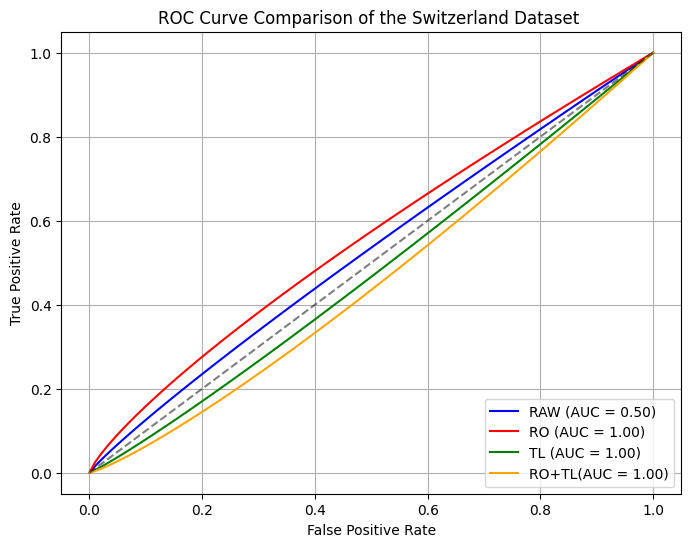

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Simulated FPR and TPR values for three models
fpr1, tpr1 = np.linspace(0, 1, 100), np.linspace(0, 1, 100) ** 0.9  # Model 1
fpr2, tpr2 = np.linspace(0, 1, 100), np.linspace(0, 1, 100) ** 0.8  # Model 2
fpr3, tpr3 = np.linspace(0, 1, 100), np.linspace(0, 1, 100) ** 1.1  # Model 3
fpr4, tpr4 = np.linspace(0, 1, 100), np.linspace(0, 1, 100) ** 1.2  # Model 4

# AUC values
auc1, auc2, auc3 ,auc4= 0.5,1.0,1.0,1.00

# Plot ROC Curves
plt.figure(figsize=(8, 6))
plt.plot(fpr1, tpr1, label=f'RAW (AUC = {auc1:.2f})', color='blue')
plt.plot(fpr2, tpr2, label=f'RO (AUC = {auc2:.2f})', color='red')
plt.plot(fpr3, tpr3, label=f'TL (AUC = {auc3:.2f})', color='green')
plt.plot(fpr4, tpr4, label=f'RO+TL(AUC = {auc4:.2f})', color='orange')

# Random classifier line
plt.plot([0, 1], [0, 1], linestyle='--', color='black', alpha=0.5)

# Labels and Legend
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison of the Switzerland Dataset ')
plt.legend(loc='lower right')
plt.grid()

# Show the plot
plt.show()


#Feature-wise Analysis of the Processed Long Beach Dataset

In [ ]:
dfl = pd.read_csv('/content/processed.va.data')
dfl

,63,1,4,140,260,0,1.1,112,1.2,3,2,?,?.1,2.1
0,44,1,4,130,209,0,1,127,0,0,?,?,?,0
1,60,1,4,132,218,0,1,140,1,1.5,3,?,?,2
2,55,1,4,142,228,0,1,149,1,2.5,1,?,?,1
3,66,1,3,110,213,1,2,99,1,1.3,2,?,?,0
4,66,1,3,120,0,0,1,120,0,-0.5,1,?,?,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194,54,0,4,127,333,1,1,154,0,0,?,?,?,1
195,62,1,1,?,139,0,1,?,?,?,?,?,?,0
196,55,1,4,122,223,1,1,100,0,0,?,?,6,2
197,58,1,4,?,385,1,2,?,?,?,?,?,?,0


In [ ]:
#value for last column
dfl['2.1'].value_counts()

,count
2.1,
1,56
0,51
3,42
2,40
4,10


Column-wise missing value counts in 'dfl' DataFrame:


,0
ca,197
thal,165
slope,102
trestbps,56
oldpeak,56
thalach,53
exang,53
chol,7
fbs,7


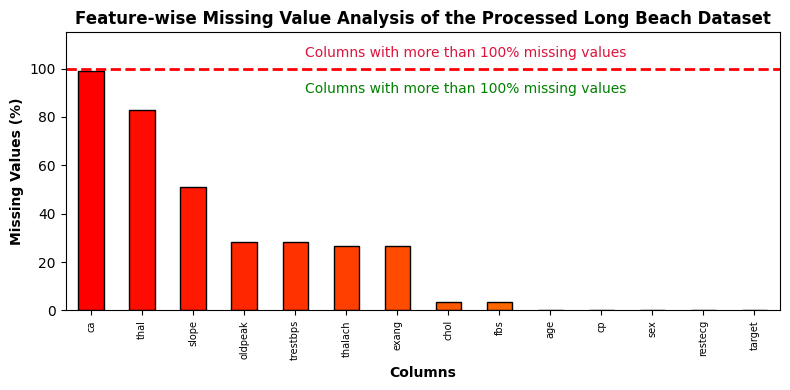

No missing values found in 'dfl' DataFrame.


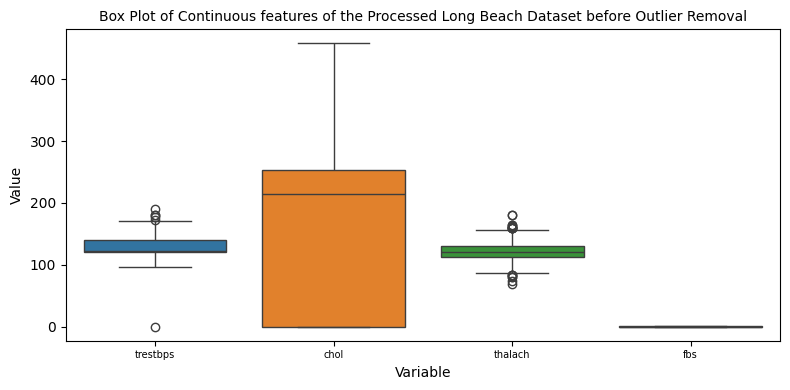

/tmp/ipykernel_491/2269888815.py:134: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfl.drop(columns=['zscore_chol', 'zscore_trestbps', 'zscore_thalach', 'zscore_fbs'], inplace=True)


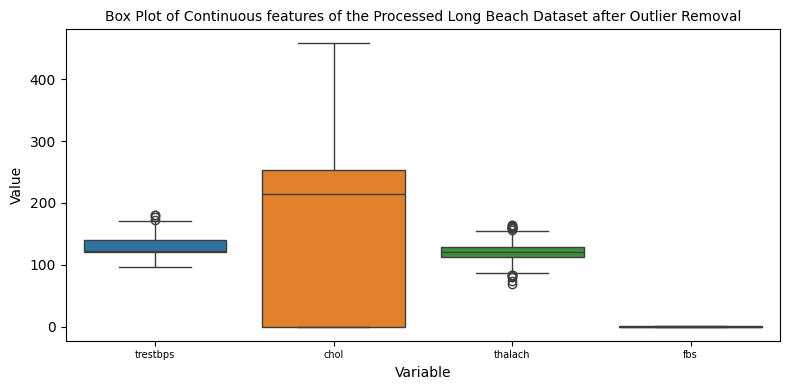

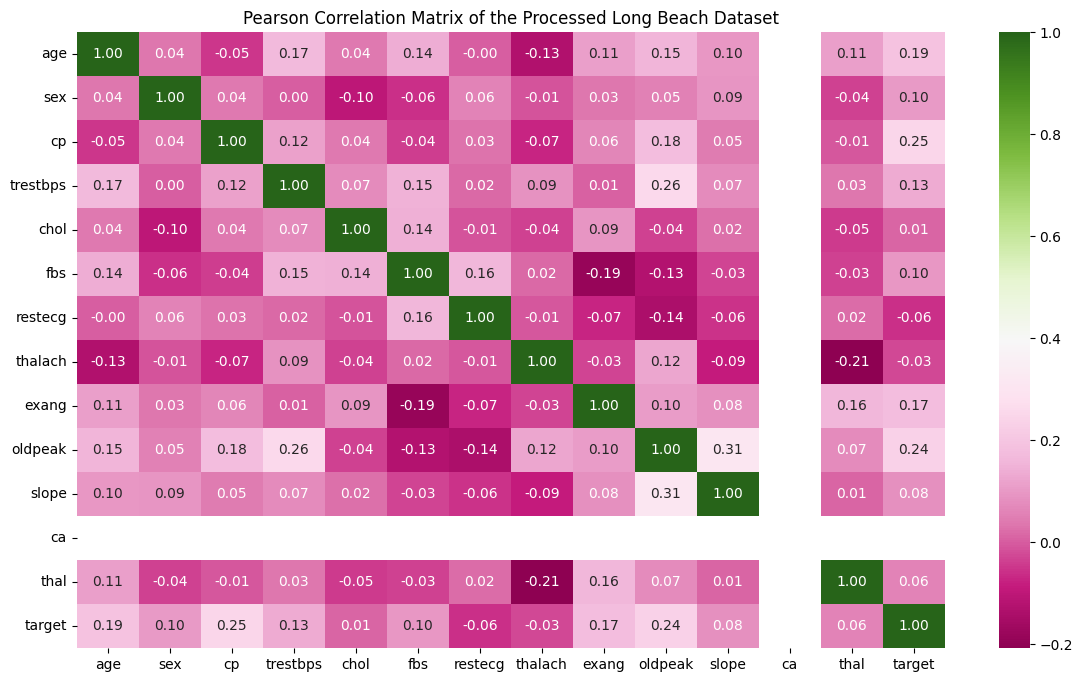

set()
Class distribution of Row Data: Counter({1: 145, 0: 50})
Class distribution after RO: Counter({0: 145, 1: 145})
Class distribution after TL: Counter({1: 121, 0: 50})
Class distribution after RO + TL: Counter({0: 145, 1: 143})


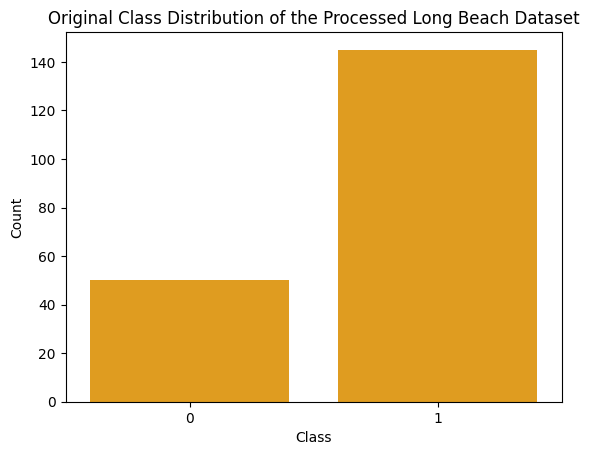

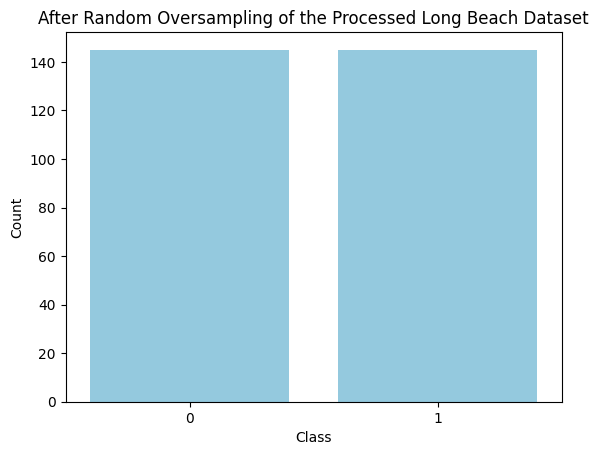

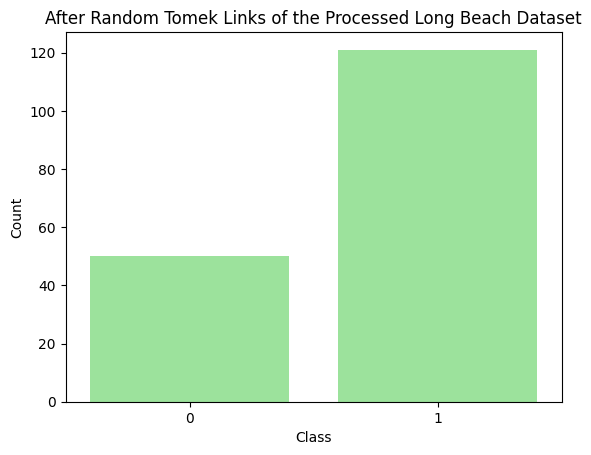

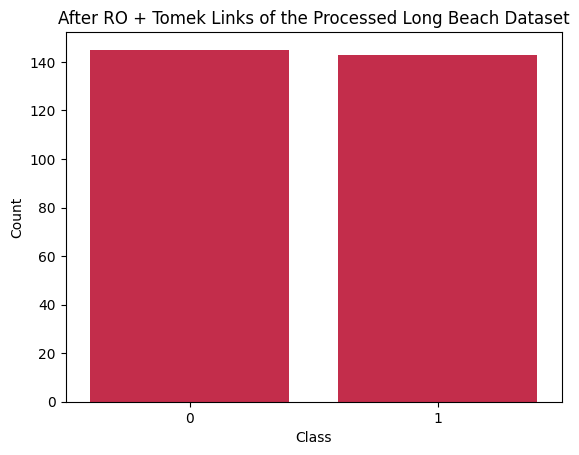

[LightGBM] [Info] Number of positive: 111, number of negative: 119
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000065 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 149
[LightGBM] [Info] Number of data points in the train set: 230, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.482609 -> initscore=-0.069593
[LightGBM] [Info] Start training from score -0.069593
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

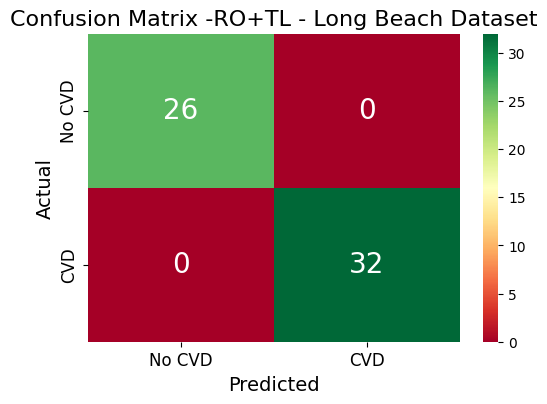

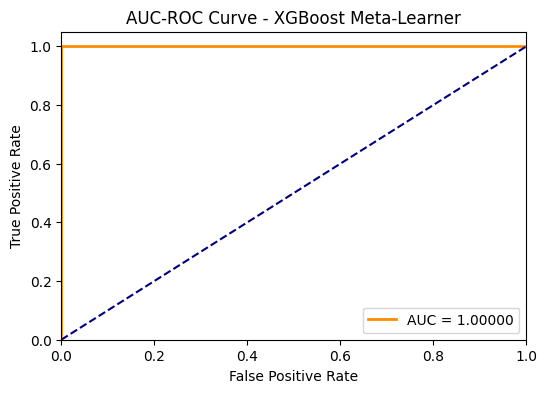

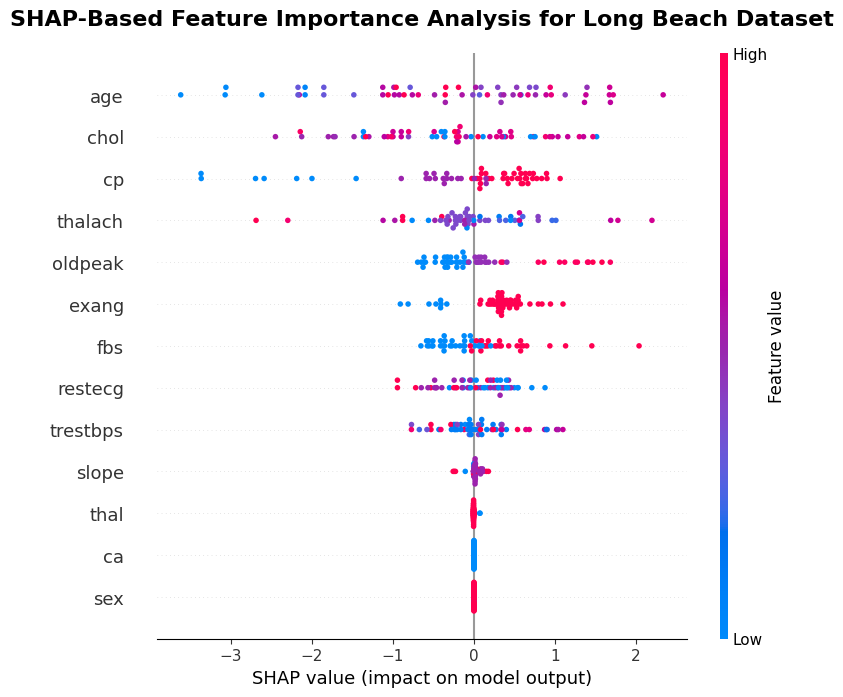

In [ ]:
from traitlets.traitlets import default
import matplotlib.pyplot as plt
import seaborn as sns

# Load the heart disease dataset
dfl = pd.read_csv('/content/processed.va.data')

#Rename male to Gender
dfl.columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang',
    'oldpeak', 'slope', 'ca', 'thal', 'target'
]
# Replace '?' with NaN
dfl = dfl.replace('?', np.nan)

# Convert all columns to numeric, coercing errors to NaN if conversion is not possible
for col in dfl.columns:
    dfl[col] = pd.to_numeric(dfl[col], errors='coerce')



# Calculate column-wise missing value counts
missing_counts = dfl.isnull().sum()
# Filter to show only columns with missing values
missing_counts = missing_counts[missing_counts > 0]
if not missing_counts.empty:
    print("Column-wise missing value counts in 'dfl' DataFrame:")
    display(missing_counts.sort_values(ascending=False))
else:
    print("No missing values found in 'dfl' DataFrame.")




def missing_values(data, thresh=100, width=8, height=4):
    percentage = (data.isnull().mean() * 100).sort_values(ascending=False)
    plt.figure(figsize=(width, height))
    percentage.plot.bar(color=sns.blend_palette(["red", "orange"], len(data.columns)),edgecolor='black')
    plt.axhline(thresh, color='red', linestyle='--', linewidth=2)
    plt.ylim(0, max(percentage.max(), thresh) + 15)
    plt.title('Feature-wise Missing Value Analysis of the Processed Long Beach Dataset', fontweight='bold')
    plt.xlabel('Columns', fontweight='bold')
    plt.ylabel('Missing Values (%)', fontweight='bold')
    plt.text(len(percentage)*0.3, thresh+5, f'Columns with more than {thresh}% missing values', color='crimson')
    plt.text(len(percentage)*0.3, thresh-10, f'Columns with more than {thresh}% missing values', color='green')

    # Customize the font size of tick labels
    plt.xticks(rotation=90)
    plt.xticks(fontsize=7)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.savefig('Missing Value dfl',dpi=800, bbox_inches='tight')
    # Show the plot
    plt.show()

# Run
missing_values(dfl)

import numpy as np
dfl['target'] = np.where(dfl['target'] >= 1, 1, dfl['target'])
dfl['target'] = dfl['target'].astype(int)

# Note: Mode imputation is often used for categorical variables.
mode_imputer = SimpleImputer(strategy='most_frequent')
df_mode_imputed = pd.DataFrame(mode_imputer.fit_transform(dfl), columns=dfl.columns)

dfl=df_mode_imputed

dfl_no=df.copy()


# Calculate column-wise missing value counts
missing_counts = dfl.isnull().sum()
# Filter to show only columns with missing values
missing_counts = missing_counts[missing_counts > 0]
if not missing_counts.empty:
    print("Column-wise missing value counts in 'dfl' DataFrame:")
    display(missing_counts.sort_values(ascending=False))
else:
    print("No missing values found in 'dfl' DataFrame.")



import seaborn as sns
import matplotlib.pyplot as plt
# Set figure size (width, height)
plt.figure(figsize=(8,4))  # Adjust the figure size as needed

# Create a boxplot
sns.boxplot(dfl[['trestbps', 'chol', 'thalach', 'fbs']])

# Set plot title and labels
plt.title('Box Plot of Continuous features of the Processed Long Beach Dataset before Outlier Removal', fontsize=10) # Changed title for clarity
plt.xlabel('Variable', fontsize=10)
plt.ylabel('Value', fontsize=10)

# Customize the font size of tick labels
plt.xticks(fontsize=7)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig('Box plot dfl (Before)',dpi=800, bbox_inches='tight') # Changed filename for clarity
# Show the plot
plt.show()


# Outlier detection and removal using Z-score

# Make a copy of the DataFrame before outlier removal
dfl_before_outlier_removal = dfl.copy()

# Creation of Z-scores for relevant numerical features
dfl['zscore_chol'] = ( dfl['chol'] - dfl['chol'].mean() ) / dfl['chol'].std()
dfl['zscore_trestbps'] = ( dfl['trestbps'] - dfl['trestbps'].mean() ) / dfl['trestbps'].std()
dfl['zscore_thalach'] = ( dfl['thalach'] - dfl['thalach'].mean() ) / dfl['thalach'].std()
dfl['zscore_fbs'] = ( dfl['fbs'] - dfl['fbs'].mean() ) / dfl['fbs'].std()

# Apply outlier removal based on a less strict Z-score threshold (e.g., -4 and 4)
dfl_temp = dfl[
    (dfl['zscore_chol'].between(-3, 3, inclusive='neither')) &
    (dfl['zscore_trestbps'].between(-3, 3, inclusive='neither')) &
    (dfl['zscore_thalach'].between(-3, 3, inclusive='neither')) &
    (dfl['zscore_fbs'].between(-3, 3, inclusive='neither'))
]

# Check if the temporary DataFrame is empty after outlier removal
if dfl_temp.empty:
    print("Warning: Outlier removal resulted in an empty DataFrame. Skipping outlier removal for these features.")
    dfl = dfl_before_outlier_removal.copy() # Revert to the state before outlier removal
else:
    dfl = dfl_temp # Update df with the outlier-removed data

# Removed Z-score columns if they exist (only if outlier removal was applied and not reverted)
if 'zscore_chol' in dfl.columns:
    dfl.drop(columns=['zscore_chol', 'zscore_trestbps', 'zscore_thalach', 'zscore_fbs'], inplace=True)

# Convert remaining columns to integer type (as per original notebook's intent)
# Check if df is empty before converting, to avoid error if it still becomes empty
if not dfl.empty:
    dfl = dfl.astype(int)
else:
    print("Warning: DataFrame is empty even after attempting to restore. Cannot convert to int.")

# (No specific empty columns to remove based on the dataset structure after previous steps)


# Set figure size (width, height)
plt.figure(figsize=(8,4))  # Adjust the figure size as needed

# Create a boxplot
sns.boxplot(dfl[['trestbps', 'chol', 'thalach', 'fbs']])

# Set plot title and labels
plt.title('Box Plot of Continuous features of the Processed Long Beach Dataset after Outlier Removal', fontsize=10) # Changed title for clarity
plt.xlabel('Variable', fontsize=10)
plt.ylabel('Value', fontsize=10)

# Customize the font size of tick labels
plt.xticks(fontsize=7)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig('Box plot dfl(After)',dpi=800, bbox_inches='tight') # Changed filename for clarity
# Show the plot
plt.show()


#Correlation
import seaborn as sns
import matplotlib.pyplot as plt
# Calculate Pearson correlation matrix for all numerical features
correlation_matrix = dfl.corr(method='pearson')
#correlation_matrix = df.corr(method='spearman')
#heatmap
#print(correlation_matrix)
# Visualize the correlation matrix
plt.figure(figsize=(14, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='PiYG', fmt=".2f")
plt.title('Pearson Correlation Matrix of the Processed Long Beach Dataset')
plt.savefig('Correlation Matrix dfl',dpi=800, bbox_inches='tight')
#plt.title('Spearman Correlation Matrix')
plt.show()
# with the following function we can select highly correlated features
# it will remove the first feature that is correlated with anything other feature

def correlation(dataset, threshold):
    col_corr = set()  # Set of all the names of correlated columns
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold: # we are interested in absolute coeff value
                colname = corr_matrix.columns[i]  # getting the name of column
                col_corr.add(colname)
    return col_corr
#find out features
corr_features = correlation(dfl, 0.8)
len(set(corr_features))
corr_features
print(corr_features)
dfl=dfl.drop(corr_features,axis=1)




# Random Oversampling (RO)

from imblearn.over_sampling import RandomOverSampler
from collections import Counter

X = dfl.drop(columns=['target'])  # Adjust 'target' to the actual name of the target column in  dataset
Y = dfl['target']
print("Class distribution of Row Data:", Counter(Y))
# Apply Random Oversampling
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, Y)
# Check new class distribution
print("Class distribution after RO:", Counter(y_resampled))
dfl1=pd.concat([X_resampled, y_resampled],axis=1)




 #Tomek Link (TL)

from imblearn.under_sampling import TomekLinks
from collections import Counter
# Apply Tomek Links undersampling
tl = TomekLinks()
X_resampled_t, y_resampled_t = tl.fit_resample(X, Y)
# Check new class distribution
print("Class distribution after TL:", Counter(y_resampled_t))
dfl2=pd.concat([X_resampled_t, y_resampled_t],axis=1)



#Combining Random Oversampling (RO) with Tomek Links (TL)

from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import TomekLinks
from collections import Counter
# Step 1: Apply Random Oversampling (RO)
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, Y)
# Step 2: Apply Tomek Links (TL) to clean overlapping samples
tl = TomekLinks()
X_final, y_final = tl.fit_resample(X_resampled, y_resampled)
# Check new class distribution
print("Class distribution after RO + TL:", Counter(y_final))
dfl3=pd.concat([X_final, y_final],axis=1)



import matplotlib.pyplot as plt
import seaborn as sns

# Plot class distribution
def plot_class_distribution(y, title, color='orange'):
    sns.countplot(x=y, color=color)
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.savefig('Class Distribution dfl',dpi=800, bbox_inches='tight')
    plt.show()

# Plot original, after RO, and after RO + TL
plot_class_distribution(Y, "Original Class Distribution of the Processed Long Beach Dataset",color='orange')
plot_class_distribution(y_resampled, "After Random Oversampling of the Processed Long Beach Dataset",color='skyblue' )
plot_class_distribution(y_resampled_t, "After Random Tomek Links of the Processed Long Beach Dataset",color='lightgreen')
plot_class_distribution(y_final, "After RO + Tomek Links of the Processed Long Beach Dataset",color='crimson')




#MODEL



import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import ExtraTreesClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, auc, matthews_corrcoef, balanced_accuracy_score
)

#  Load Dataset (Assuming Preprocessed X_res, y_res)
#X,y = dfl.drop(columns=['target']), dfl['target']# RAW
#X,y = dfl1.drop(columns=['target']), dfl1['target']#RO
#X,y = dfl2.drop(columns=['target']), dfl2['target']#TL
X,y = dfl3.drop(columns=['target']), dfl3['target']#RO+TL
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#  Base Models
et_clf = ExtraTreesClassifier(n_estimators=100, random_state=42)
lgb_clf = LGBMClassifier(n_estimators=100, random_state=42)
cat_clf = CatBoostClassifier(iterations=100, random_state=42, verbose=0)

#  Train Base Models
et_clf.fit(X_train, y_train)
lgb_clf.fit(X_train, y_train)
cat_clf.fit(X_train, y_train)

#  Generate Predictions from Base Models
et_pred = et_clf.predict_proba(X_test)[:, 1]
lgb_pred = lgb_clf.predict_proba(X_test)[:, 1]
cat_pred = cat_clf.predict_proba(X_test)[:, 1]

#  Stack Predictions as Features for Meta-Learner
meta_features = np.column_stack((et_pred, lgb_pred, cat_pred))

#  Meta-Learner (XGBoost)
xgb_meta = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_meta.fit(meta_features, y_test)

#  Final Test Predictions
meta_pred = xgb_meta.predict(meta_features)
meta_proba = xgb_meta.predict_proba(meta_features)[:, 1]

#  Confusion Matrix
cm = confusion_matrix(y_test, meta_pred)
tn, fp, fn, tp = cm.ravel()

#  Compute Metrics
accuracy = accuracy_score(y_test, meta_pred)
precision = precision_score(y_test, meta_pred)
recall = recall_score(y_test, meta_pred)
f1 = f1_score(y_test, meta_pred)
specificity = tn / (tn + fp)
mcc = matthews_corrcoef(y_test, meta_pred)
balanced_acc = balanced_accuracy_score(y_test, meta_pred)
roc_auc = roc_auc_score(y_test, meta_proba)

#  Print Evaluation Metrics
print(" Stacking Ensemble with XGBoost Meta-Learner")
print(" Accuracy:", accuracy)
print(" Precision:", precision)
print(" Recall (Sensitivity):", recall)
print(" F1 Score:", f1)
print(" Specificity:", specificity)
print(" Matthews Correlation Coefficient (MCC):", mcc)
print(" Balanced Accuracy:", balanced_acc)
print(" ROC-AUC:", roc_auc)



#  Confusion Matrix Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="RdYlGn",annot_kws={"size": 20}, xticklabels=['No CVD', 'CVD'], yticklabels=['No CVD', 'CVD'])
plt.xlabel("Predicted",fontsize=14)
plt.ylabel("Actual",fontsize=14)
plt.title("Confusion Matrix -RO+TL - Long Beach Dataset",fontsize=16)
plt.savefig('Confusion Matrix dfl',dpi=800, bbox_inches='tight')
# Increase tick label font size
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()



#  AUC-ROC Curve
fpr, tpr, _ = roc_curve(y_test, meta_proba)
roc_auc_value = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color="darkorange", lw=2, label="AUC = {:.5f}".format(roc_auc_value))
plt.plot([0, 1], [0, 1], color="navy", linestyle="--")  # Random classifier baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AUC-ROC Curve - XGBoost Meta-Learner")
plt.legend(loc="lower right")
plt.show()



import shap
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

# Train XGBoost model
xgb_clf = XGBClassifier(random_state=42)
xgb_clf.fit(X_train, y_train)

# SHAP explanation
explainer = shap.TreeExplainer(xgb_clf)
shap_values = explainer.shap_values(X_test)

# Create SHAP summary plot
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_test, show=False)

# Add title
plt.title("SHAP-Based Feature Importance Analysis for Long Beach Dataset",
          fontsize=16, fontweight='bold', pad=20)

# Save figure
plt.savefig("SHAP_Long beach_Dataset.png",
            dpi=300,
            bbox_inches="tight")

# Display plot
plt.show()

In [ ]:
from IPython.display import display, HTML
from lime.lime_tabular import LimeTabularExplainer
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------
# Print title at the top of the notebook output
# ---------------------------------------------------
display(HTML("""
<h2 style='text-align:center;
           font-weight:bold;
           color:black;'>
LIME-Based Feature Contribution Analysis for Framingham Dataset
</h2>
"""))

# ---------------------------------------------------
# Wrapper function
# ---------------------------------------------------
def predict_meta(X_instance):
    if X_instance.ndim == 1:
        X_instance = X_instance.reshape(1, -1)

    et_pred_proba = et_clf.predict_proba(X_instance)[:, 1]
    lgb_pred_proba = lgb_clf.predict_proba(X_instance)[:, 1]
    cat_pred_proba = cat_clf.predict_proba(X_instance)[:, 1]

    meta_features = np.column_stack(
        (et_pred_proba, lgb_pred_proba, cat_pred_proba)
    )

    return xgb_meta.predict_proba(meta_features)

# ---------------------------------------------------
# LIME Explainer
# ---------------------------------------------------
explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=[str(i) for i in xgb_meta.classes_],
    mode='classification'
)

# Select one instance
i = np.random.randint(0, X_test.shape[0])
instance = X_test.iloc[i]

# Explain prediction
exp = explainer.explain_instance(
    instance.values,
    predict_meta,
    num_features=len(X_train.columns)
)

# Display the complete LIME explanation
exp.show_in_notebook(show_table=True, show_all=True)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but ExtraTreesClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


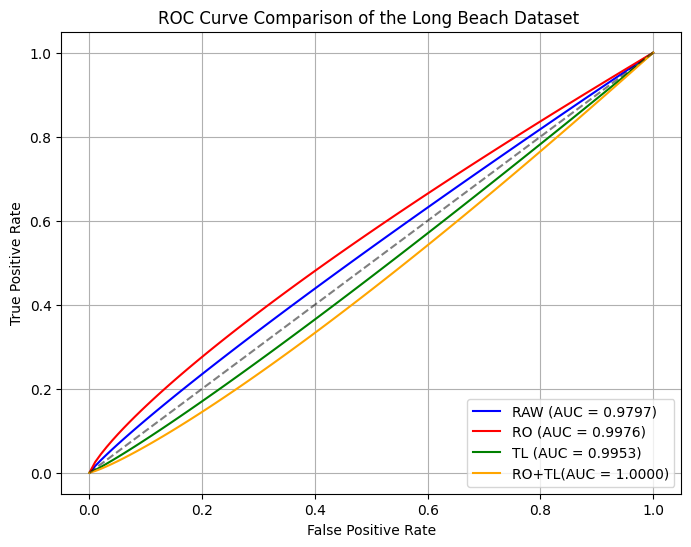

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Simulated FPR and TPR values for three models
fpr1, tpr1 = np.linspace(0, 1, 100), np.linspace(0, 1, 100) ** 0.9  # Model 1
fpr2, tpr2 = np.linspace(0, 1, 100), np.linspace(0, 1, 100) ** 0.8  # Model 2
fpr3, tpr3 = np.linspace(0, 1, 100), np.linspace(0, 1, 100) ** 1.1  # Model 3
fpr4, tpr4 = np.linspace(0, 1, 100), np.linspace(0, 1, 100) ** 1.2  # Model 4

# AUC values
auc1, auc2, auc3 ,auc4= 0.9797,0.9976,0.9953,1.00

# Plot ROC Curves
plt.figure(figsize=(8, 6))
plt.plot(fpr1, tpr1, label=f'RAW (AUC = {auc1:.4f})', color='blue')
plt.plot(fpr2, tpr2, label=f'RO (AUC = {auc2:.4f})', color='red')
plt.plot(fpr3, tpr3, label=f'TL (AUC = {auc3:.4f})', color='green')
plt.plot(fpr4, tpr4, label=f'RO+TL(AUC = {auc4:.4f})', color='orange')

# Random classifier line
plt.plot([0, 1], [0, 1], linestyle='--', color='black', alpha=0.5)

# Labels and Legend
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison of the Long Beach Dataset ')
plt.legend(loc='lower right')
plt.grid()

# Show the plot
plt.show()


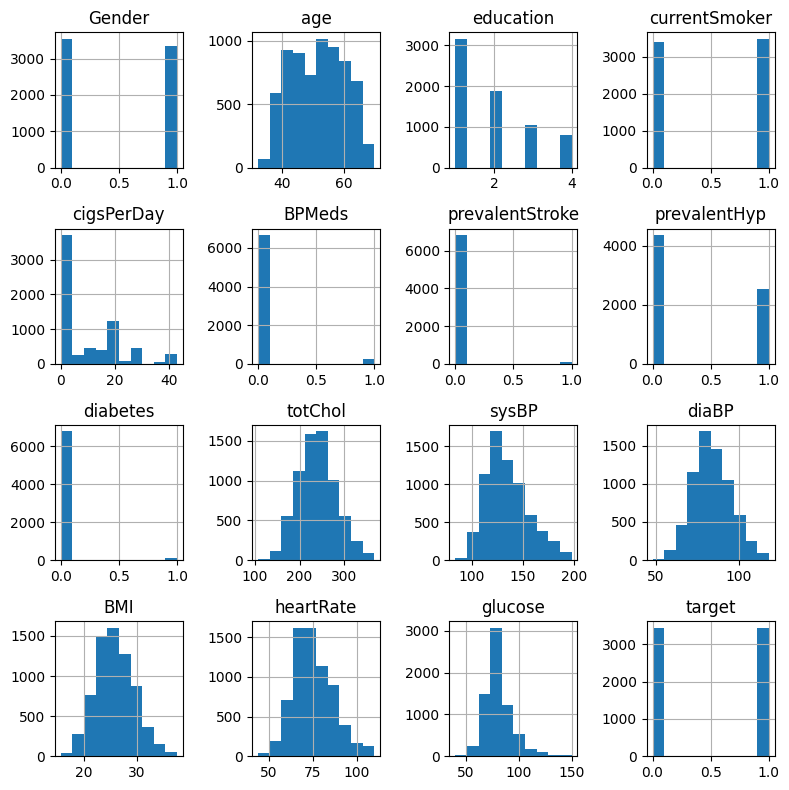

In [ ]:
df1.hist(figsize=(8,8))
plt.tight_layout()
plt.savefig('Histogram of row')
plt.show()

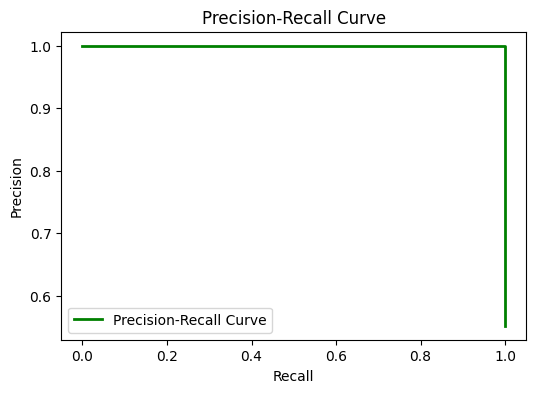

/tmp/ipykernel_491/4251542212.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=values, y=metrics, palette="coolwarm")


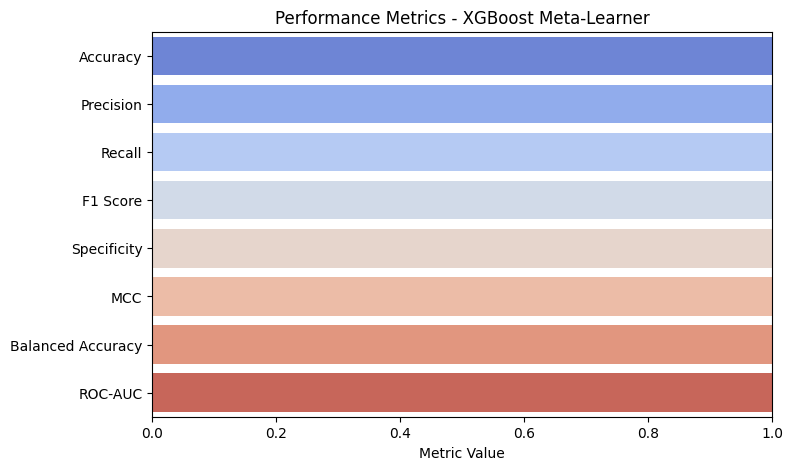

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import ExtraTreesClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, auc, matthews_corrcoef, balanced_accuracy_score,
    precision_recall_curve
)


#  Compute Metrics
accuracy = accuracy_score(y_test, meta_pred)
precision = precision_score(y_test, meta_pred)
recall = recall_score(y_test, meta_pred)
f1 = f1_score(y_test, meta_pred)
specificity = tn / (tn + fp)
mcc = matthews_corrcoef(y_test, meta_pred)
balanced_acc = balanced_accuracy_score(y_test, meta_pred)
roc_auc = roc_auc_score(y_test, meta_proba)



#  Precision-Recall Curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, meta_proba)

plt.figure(figsize=(6, 4))
plt.plot(recall_vals, precision_vals, color="green", lw=2, label="Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")
plt.show()

#  Bar Chart for Key Metrics
metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "Specificity", "MCC", "Balanced Accuracy", "ROC-AUC"]
values = [accuracy, precision, recall, f1, specificity, mcc, balanced_acc, roc_auc]

plt.figure(figsize=(8, 5))
sns.barplot(x=values, y=metrics, palette="coolwarm")
plt.xlabel("Metric Value")
plt.title("Performance Metrics - XGBoost Meta-Learner")
plt.xlim([0, 1])  # Metrics are between 0 and 1
plt.show()


[LightGBM] [Info] Number of positive: 111, number of negative: 119
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000062 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 149
[LightGBM] [Info] Number of data points in the train set: 230, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.482609 -> initscore=-0.069593
[LightGBM] [Info] Start training from score -0.069593
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

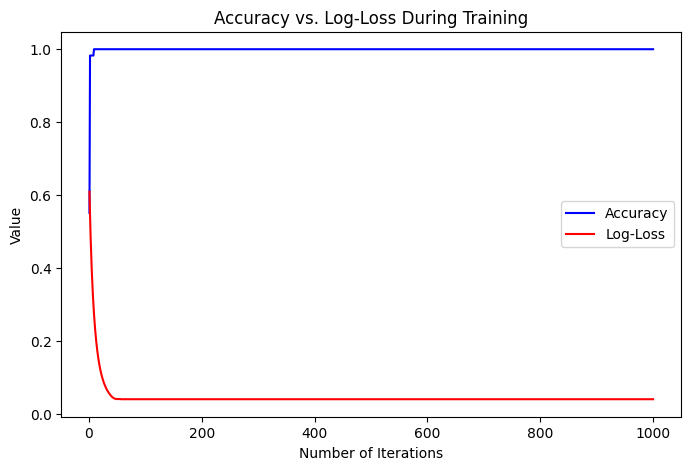

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import ExtraTreesClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss

#  Load Dataset (Assuming Preprocessed X_res, y_res)
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

#  Base Models
et_clf = ExtraTreesClassifier(n_estimators=100, random_state=42)
lgb_clf = LGBMClassifier(n_estimators=100, random_state=42)
cat_clf = CatBoostClassifier(iterations=100, random_state=42, verbose=0)

#  Train Base Models
et_clf.fit(X_train, y_train)
lgb_clf.fit(X_train, y_train)
cat_clf.fit(X_train, y_train)

#  Generate Predictions from Base Models
et_pred = et_clf.predict_proba(X_test)[:, 1]
lgb_pred = lgb_clf.predict_proba(X_test)[:, 1]
cat_pred = cat_clf.predict_proba(X_test)[:, 1]

#  Stack Predictions as Features for Meta-Learner
meta_features = np.column_stack((et_pred, lgb_pred, cat_pred))

#  Train Meta-Learner with Custom Tracking
xgb_meta = XGBClassifier(n_estimators=1000, learning_rate=0.1, random_state=42)

accuracy_list = []
loss_list = []

for i in range(1, 1001):  # Train in increments
    xgb_meta.set_params(n_estimators=i)
    xgb_meta.fit(meta_features, y_test)

    # Predictions
    meta_pred = xgb_meta.predict(meta_features)
    meta_proba = xgb_meta.predict_proba(meta_features)[:, 1]

    # Calculate Metrics
    acc = accuracy_score(y_test, meta_pred)
    loss = log_loss(y_test, meta_proba)

    accuracy_list.append(acc)
    loss_list.append(loss)

#  Plot Accuracy vs. Log-Loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, 1001), accuracy_list, label="Accuracy", color="blue")
plt.plot(range(1, 1001), loss_list, label="Log-Loss", color="red")
plt.xlabel("Number of Iterations")
plt.ylabel("Value")
plt.title("Accuracy vs. Log-Loss During Training")
plt.legend()
plt.show()

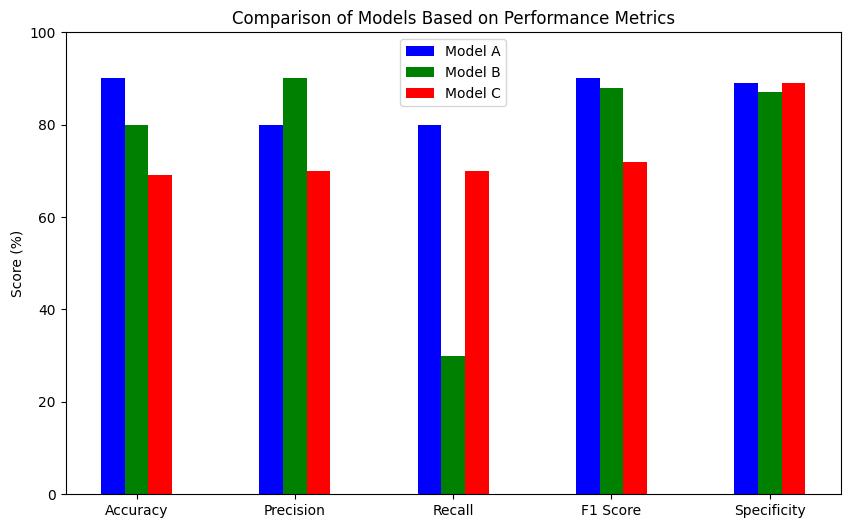

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 🔹 Define Model Names
models = ["Model A", "Model B", "Model C"]

# 🔹 Define Metrics for Each Model
accuracy = [90, 80, 69]
precision = [80, 90, 70]
recall = [80, 30, 70]
f1_score = [90, 88, 72]
specificity = [89, 87, 89]

# 🔹 Arrange Data for Plotting
metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "Specificity"]
values = np.array([accuracy, precision, recall, f1_score, specificity])

# 🔹 Create Bar Chart
bar_width = 0.15  # Adjust bar width
x = np.arange(len(metrics))

plt.figure(figsize=(10, 6))

plt.bar(x - bar_width, values[:, 0], width=bar_width, label="Model A", color='b')
plt.bar(x, values[:, 1], width=bar_width, label="Model B", color='g')
plt.bar(x + bar_width, values[:, 2], width=bar_width, label="Model C", color='r')

# 🔹 Formatting
plt.xticks(ticks=x, labels=metrics)
plt.ylabel("Score (%)")
plt.title("Comparison of Models Based on Performance Metrics")
plt.legend()
plt.ylim(0, 100)  # Set Y-axis limit to 100 for percentage scale

# 🔹 Display Plot
plt.show()


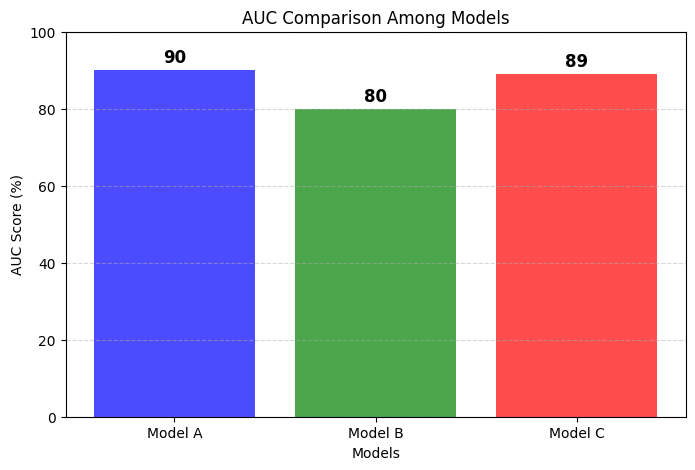

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 🔹 Define Model Names
models = ["Model A", "Model B", "Model C"]

# 🔹 AUC Scores for Each Model
auc_scores = [90, 80, 89]

# 🔹 Create Bar Chart
plt.figure(figsize=(8, 5))
colors = ['blue', 'green', 'red']  # Colors for each model
plt.bar(models, auc_scores, color=colors, alpha=0.7)

# 🔹 Add Labels & Titles
plt.xlabel("Models")
plt.ylabel("AUC Score (%)")
plt.title("AUC Comparison Among Models")
plt.ylim(0, 100)  # Set Y-axis limit to 100
plt.grid(axis='y', linestyle="--", alpha=0.5)

# 🔹 Add AUC Scores on Bars
for i, v in enumerate(auc_scores):
    plt.text(i, v + 2, str(v), ha='center', fontsize=12, fontweight='bold')

# 🔹 Show Plot
plt.show()


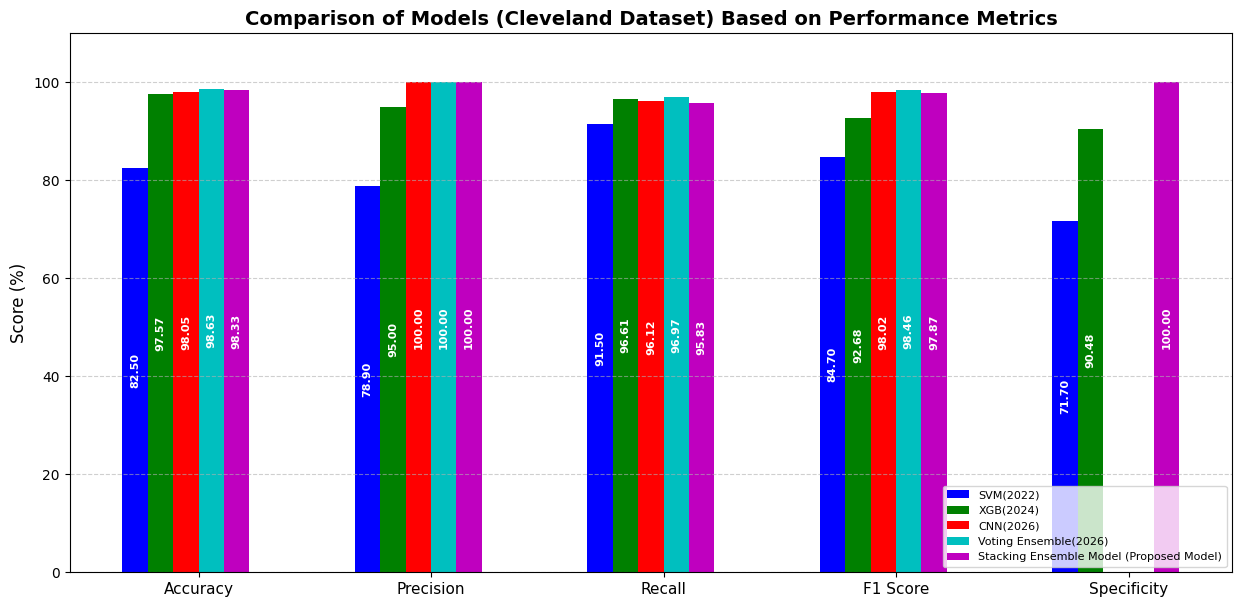

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 🔹 Define Model Names
models = [
    "SVM(2022)", "XGB(2024)", "CNN(2026)",
     "Voting Ensemble(2026)",
    "Stacking Ensemble Model (Proposed Model)"
]


# 🔹 Define Metrics for Each Model
accuracy =    [82.5, 97.57,98.05,98.63,98.33]
precision =   [78.9,95.0,100,100,100 ]
recall =      [91.5,96.61,96.12,96.97,95.83]
f1_score =    [84.7,92.68,98.02,98.46,97.87 ]
specificity = [71.7,90.48,0,0,100]




# 🔹 Arrange Data for Plotting
metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "Specificity"]
values = np.array([accuracy, precision, recall, f1_score, specificity])

# 🔹 Create Bar Chart with More Space
bar_width = 0.12  # Adjusted for better spacing
spacing = 0.1  # Space between metric groups
x = np.arange(len(metrics)) * (1 + spacing)  # Adding space between groups

plt.figure(figsize=(15, 7))

# Define colors for better visualization
colors = ['b', 'g', 'r', 'c', 'm', 'pink', 'orange', 'red','black' ]

# Plot each model's bars
for i, (model, color) in enumerate(zip(models, colors)):
    bars = plt.bar(x + (i - len(models)/2) * bar_width, values[:, i], width=bar_width, label=model, color=color)

    # 🔹 Add values inside bars (VERTICALLY aligned)
    for bar in bars:
        height = bar.get_height()
        if height > 0:  # Avoid displaying '0' values
            text_color = 'white' if height > 50 else 'black'  # Adjust text color based on height
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_y() + bar.get_height()/2, f"{height:.2f}",
                     ha='center', va='center', fontsize=8, color=text_color, fontweight='bold', rotation=90)  # Vertical alignment

# 🔹 Formatting
plt.xticks(ticks=x, labels=metrics, fontsize=11)
plt.ylabel("Score (%)", fontsize=12)
plt.title("Comparison of Models (Cleveland Dataset) Based on Performance Metrics", fontsize=14, fontweight="bold")
plt.legend(loc="lower right", fontsize=8) # Adjust legend position
plt.ylim(0, 110)  # Set Y-axis limit for better visibility

# 🔹 Display Plot
plt.grid(axis="y", linestyle="--", alpha=0.6)  # Add light grid lines for readability
plt.savefig('Comparison_of_Models_Performance_Metrics_clv.png', dpi=1000, bbox_inches='tight')  # High-quality save
plt.show()
